In [1]:
# =====================================================================
# CELDA DE COMPATIBILIDAD - Google Colab / Local
# ---------------------------------------------------------------------
# Este notebook funciona IGUAL en dos entornos:
#   * LOCAL  -> usa el venv del proyecto (Python 3.12) y el CSV de data/raw/
#   * COLAB  -> instala las dependencias y descarga el dataset al vuelo
# No hay que tocar nada: la deteccion es automatica.
# =====================================================================
import sys
import subprocess
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    print("Entorno detectado: GOOGLE COLAB -> instalando dependencias...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "pandas", "numpy", "matplotlib", "seaborn",
         "scikit-learn", "imbalanced-learn", "ucimlrepo", "xgboost"],
        check=True,
    )
    # En Colab no existe el repositorio clonado: se arma la estructura minima
    RAIZ = Path("/content/DefenzaGrado")
    (RAIZ / "data" / "raw").mkdir(parents=True, exist_ok=True)
    (RAIZ / "outputs" / "figuras").mkdir(parents=True, exist_ok=True)

    ruta_csv = RAIZ / "data" / "raw" / "desercion_estudiantil.csv"
    if not ruta_csv.exists():
        print("Descargando dataset UCI id=697 ...")
        import pandas as pd
        from ucimlrepo import fetch_ucirepo
        repo = fetch_ucirepo(id=697)
        pd.concat([repo.data.features, repo.data.targets], axis=1).to_csv(
            ruta_csv, index=False, encoding="utf-8"
        )
        print(f"Dataset guardado en {ruta_csv}")
    else:
        print("El dataset ya estaba descargado.")
else:
    print("Entorno detectado: LOCAL -> no se instala nada.")
    # El notebook vive en notebooks/, la raiz del proyecto esta un nivel arriba
    RAIZ = Path.cwd()
    if not (RAIZ / "data").exists():
        RAIZ = RAIZ.parent

# Rutas que usa TODO el notebook a partir de aqui
DIR_DATOS = RAIZ / "data" / "raw"
DIR_FIGURAS = RAIZ / "outputs" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
RUTA_CSV = DIR_DATOS / "desercion_estudiantil.csv"

print(f"\nRaiz del proyecto : {RAIZ}")
print(f"CSV del dataset   : {RUTA_CSV}  (existe: {RUTA_CSV.exists()})")
print(f"Figuras se guardan: {DIR_FIGURAS}")

Entorno detectado: LOCAL -> no se instala nada.

Raiz del proyecto : D:\_Dev\Projects\DefenzaGrado
CSV del dataset   : D:\_Dev\Projects\DefenzaGrado\data\raw\desercion_estudiantil.csv  (existe: True)
Figuras se guardan: D:\_Dev\Projects\DefenzaGrado\outputs\figuras


# Sistema de Alerta Temprana para la Desercion Estudiantil

**Examen de Grado - Ingenieria de Sistemas (UTEPSA)**
**Area:** Inteligencia Artificial | **Caso #01**
**Fecha de defensa:** 13 de agosto de 2026

---

**Objetivo:** construir un clasificador **Random Forest** que identifique, lo antes
posible, a los estudiantes con alto riesgo de desertar durante los primeros
semestres de carrera, para que la universidad pueda intervenir a tiempo.

**Dataset:** *Predicting Student Dropout and Academic Success* -- UCI Machine
Learning Repository, id **697**.
<https://archive.ics.uci.edu/dataset/697/predicting+student+dropout+and+academic+success>

**Metodologia:** CRISP-DM (Cross Industry Standard Process for Data Mining), sus
6 fases estructuran este notebook:

| # | Fase | Que se responde |
|---|------|-----------------|
| 1 | Comprension del Negocio | Que problema resolvemos y como se mide el exito |
| 2 | Comprension de los Datos | Que tenemos, en que estado, que dice el target |
| 3 | Preparacion de los Datos | Como dejamos los datos listos para el modelo |
| 4 | Modelado | Random Forest: entrenamiento y ajuste de hiperparametros |
| 5 | Evaluacion | Metricas, matriz de confusion, ROC, importancia de variables |
| 6 | Implementacion | Como se llevaria esto a produccion en la universidad |

> **Nota sobre este notebook:** las 6 fases estan resueltas y verificadas,
> con cada decision documentada donde se toma -- no al final, como un anexo.

---

## Fase 1 - Comprension del Negocio

### 1.1 El problema

La desercion estudiantil temprana (primeros 4 semestres) le cuesta a la
universidad matriculas perdidas, indicadores de calidad a la baja y capacidad
instalada ociosa; y le cuesta al estudiante tiempo, dinero y, muchas veces, la
carrera. El problema real no es *contar* desertores al final del año: es
**detectarlos mientras todavia se puede hacer algo**.

### 1.2 Objetivo de negocio

Entregar a Bienestar Estudiantil una lista priorizada de estudiantes en riesgo,
al cierre de cada semestre, para activar tutorias, apoyo economico o
acompañamiento academico.

### 1.3 Objetivo de mineria de datos

Entrenar un clasificador **binario** (`desertor` / `no desertor`) sobre las
variables socioeconomicas, academicas y de contexto disponibles al momento de la
matricula y del primer/segundo semestre.

El target original tiene 3 clases (`Dropout`, `Enrolled`, `Graduate`) y **se
simplifica a binario**. Esa simplificacion es una decision a justificar en la
defensa (ver TODO en la Fase 3).

### 1.4 Criterio de exito

En alerta temprana, **el error caro es el falso negativo**: un estudiante que va
a desertar y el sistema no marca es una intervencion que nunca ocurrio. Un falso
positivo, en cambio, solo cuesta una tutoria de mas.

Por eso la metrica que manda es el **recall de la clase `desertor`**, acompañada
de F1 y ROC-AUC para no degradar demasiado la precision. *Accuracy* sola no
sirve: con ~32% de desertores, un modelo que diga "nadie deserta" acierta 68% y
es inutil.

### 1.5 Por que Random Forest

- Maneja mezcla de variables numericas y categoricas sin exigir escalado.
- Robusto a outliers y a relaciones no lineales.
- Entrega **importancia de variables**, que es lo que hace accionable la alerta:
  no basta con decir "este estudiante esta en riesgo", hay que decir por que.
- Menos propenso al sobreajuste que un arbol unico, gracias al bagging.

## Fase 2 - Comprension de los Datos

Se carga el dataset ya descargado por `src/cargar_datos.py` y se revisa su
forma, tipos, nulos y la distribucion del target. Esta fase **si esta resuelta**:
es el punto de partida comun para todo lo que sigue.

Si el CSV no existe todavia, ejecutar antes desde la raiz del proyecto:

```bash
python src/cargar_datos.py
```

In [2]:
# --- Librerias y configuracion global de graficos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Todas las figuras se exportan a 300 dpi para que entren con calidad en el Word
DPI_EXPORT = 300
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = DPI_EXPORT
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid", palette="deep")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SEMILLA = 42  # reproducibilidad: mismo resultado en cada corrida

print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"matplotlib   {plt.matplotlib.__version__}")
print(f"seaborn      {sns.__version__}")

pandas       3.0.5
numpy        2.5.1
matplotlib   3.11.1
seaborn      0.13.2


In [3]:
# --- Carga del dataset ---
if not RUTA_CSV.exists():
    raise FileNotFoundError(
        f"No se encontro {RUTA_CSV}.\n"
        "Ejecuta primero desde la raiz del proyecto:  python src/cargar_datos.py"
    )

df = pd.read_csv(RUTA_CSV)

print(f"Forma del dataset (filas, columnas): {df.shape}")
print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

Forma del dataset (filas, columnas): (4424, 37)
Filas    : 4,424
Columnas : 37


In [4]:
# --- Primeras filas ---
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# --- Tipos de dato, memoria y valores nulos ---
df.info()

print("\n--- Nulos por columna (solo las que tienen) ---")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
if nulos.empty:
    print("No hay valores nulos declarados en el dataset.")
else:
    print(nulos)

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [6]:
# --- Estadisticos descriptivos de las variables numericas ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [7]:
# --- Distribucion del target (3 clases originales) ---
conteo = df["Target"].value_counts()
porcentaje = df["Target"].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({"cantidad": conteo, "porcentaje": porcentaje.round(2)})
print(resumen_target)

print("\nLectura rapida:")
print(f"  - Total de estudiantes  : {len(df):,}")
print(f"  - Desertores (Dropout)  : {conteo.get('Dropout', 0):,}"
      f" ({porcentaje.get('Dropout', 0):.1f}%)")
print("  - La clase 'Enrolled' (aun cursando) es el caso ambiguo:")
print("    hay que decidir en la Fase 3 si se agrupa o se descarta.")

          cantidad  porcentaje
Target                        
Graduate      2209       49.93
Dropout       1421       32.12
Enrolled       794       17.95

Lectura rapida:
  - Total de estudiantes  : 4,424
  - Desertores (Dropout)  : 1,421 (32.1%)
  - La clase 'Enrolled' (aun cursando) es el caso ambiguo:
    hay que decidir en la Fase 3 si se agrupa o se descarta.


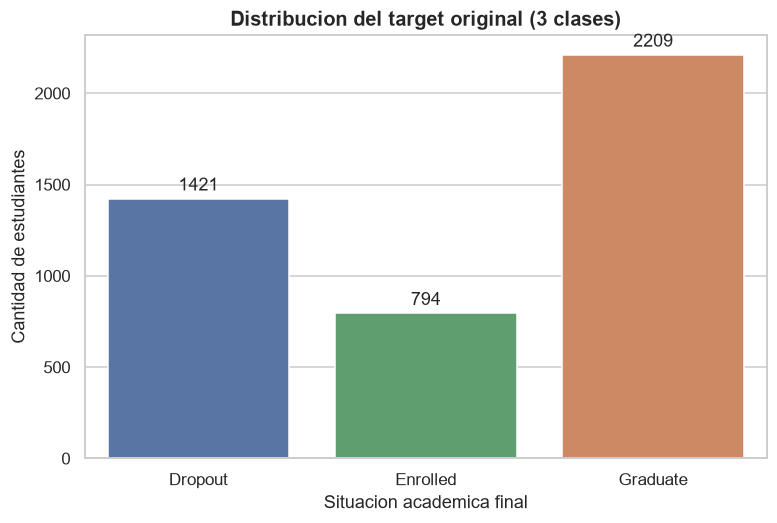

Figura guardada en: D:\_Dev\Projects\DefenzaGrado\outputs\figuras\01_distribucion_target.png


In [8]:
# --- Figura 1: distribucion del target ---
fig, ax = plt.subplots(figsize=(8, 5))

orden = ["Dropout", "Enrolled", "Graduate"]
sns.countplot(data=df, x="Target", order=orden, hue="Target",
              legend=False, ax=ax)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d", padding=3)

ax.set_title("Distribucion del target original (3 clases)", fontsize=13, weight="bold")
ax.set_xlabel("Situacion academica final")
ax.set_ylabel("Cantidad de estudiantes")

plt.savefig(DIR_FIGURAS / "01_distribucion_target.png", dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {DIR_FIGURAS / '01_distribucion_target.png'}")

### 2.1 Exploracion mas profunda (a completar)

Lo anterior es el reconocimiento minimo. El analisis exploratorio que sostiene
las decisiones de la Fase 3 todavia hay que hacerlo.

> Guia paso a paso de que se espera en cada TODO de abajo y por que le importa
> a la defensa (sin codigo resuelto): ver `08-Defensa-Grado/Guia-Fase2-EDA.md`
> en el vault.

In [9]:
# Resuelto en las celdas siguientes: separacion de columnas por naturaleza
# real -- COLUMNAS_CATEGORICAS / COLUMNAS_NUMERICAS, no por dtype, porque
# varias categoricas vienen codificadas como enteros (ej. 'Marital Status',
# 'Course') -- cardinalidad, distribuciones, comparacion por clase, matriz
# de correlacion, duplicados y valores centinela.


In [10]:
# 1. Definicion de columnas segun su naturaleza real
COLUMNAS_CATEGORICAS = [
    'Marital Status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

COLUMNAS_BINARIAS = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International'
]

COLUMNAS_NUMERICAS = [
    'Application order', 'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment', 'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
    'Inflation rate', 'GDP'
]

print(f"Categoricas : {len(COLUMNAS_CATEGORICAS)}")
print(f"Binarias    : {len(COLUMNAS_BINARIAS)}")
print(f"Numericas   : {len(COLUMNAS_NUMERICAS)}")
print(f"Total       : {len(COLUMNAS_CATEGORICAS) + len(COLUMNAS_BINARIAS) + len(COLUMNAS_NUMERICAS)} (de 36 features + 1 target)")

Categoricas : 9
Binarias    : 8
Numericas   : 19
Total       : 36 (de 36 features + 1 target)


In [11]:
print("--- Cardinalidad de variables categoricas ---")
# Iteramos sobre la lista de categoricas para ver el impacto potencial en el encoding
for col in COLUMNAS_CATEGORICAS:
    n_unicos = df[col].nunique()
    print(f"{col:25}: {n_unicos} valores unicos")

--- Cardinalidad de variables categoricas ---
Marital Status           : 6 valores unicos
Application mode         : 18 valores unicos
Course                   : 17 valores unicos
Previous qualification   : 17 valores unicos
Nacionality              : 21 valores unicos
Mother's qualification   : 29 valores unicos
Father's qualification   : 34 valores unicos
Mother's occupation      : 32 valores unicos
Father's occupation      : 46 valores unicos


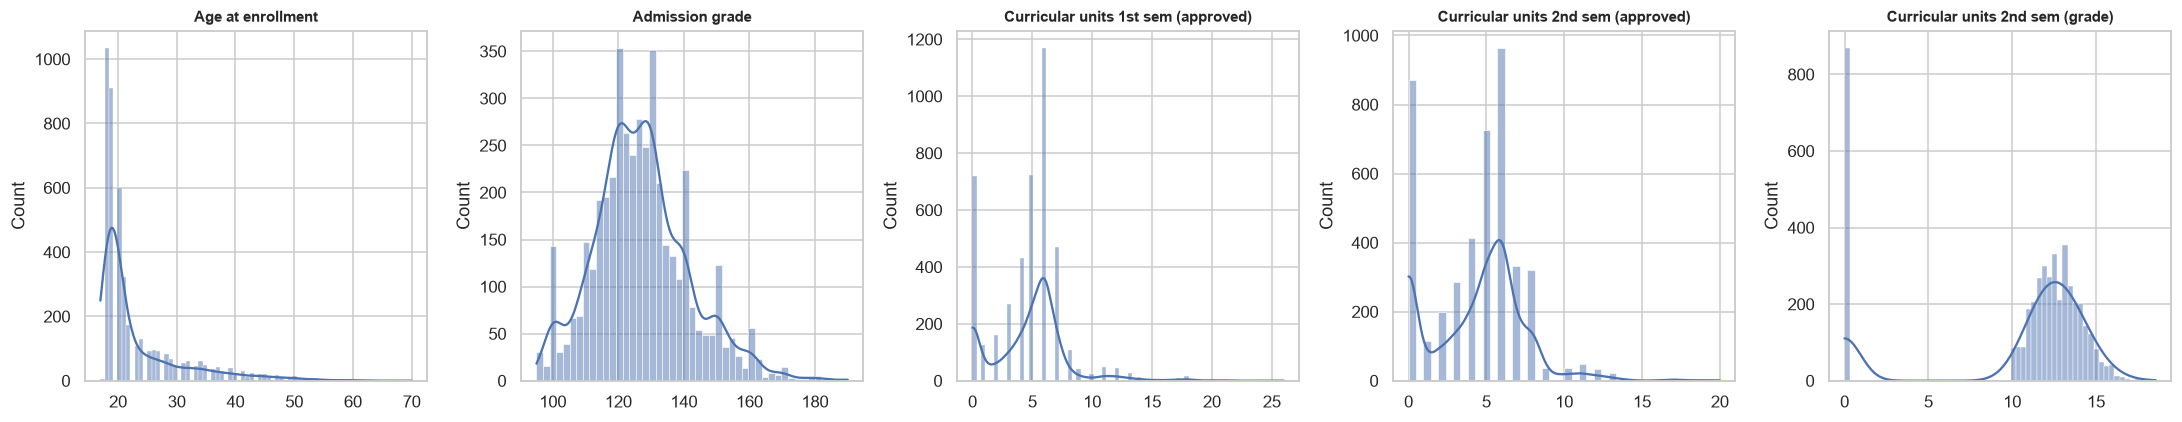

Figura guardada en: D:\_Dev\Projects\DefenzaGrado\outputs\figuras\02_distribucion_numericas.png


In [12]:
columnas_clave = [
    'Age at enrollment', 'Admission grade',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, columnas_clave):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('')

# La mayoria de los estudiantes tiene 18-22 anos, pero la distribucion es
# asimetrica a la derecha (media 23.3 > mediana 20): hay una cola de
# estudiantes no tradicionales (30+) que arrastra la media hacia arriba.
# Esa cola es poblacion de riesgo -- Age at enrollment correlaciona con
# desercion (ver TODO de correlacion mas abajo).
plt.tight_layout()
# Guardamos usando la ruta definida previamente en el notebook
ruta_fig_02 = DIR_FIGURAS / '02_distribucion_numericas.png'
plt.savefig(ruta_fig_02, dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {ruta_fig_02}")

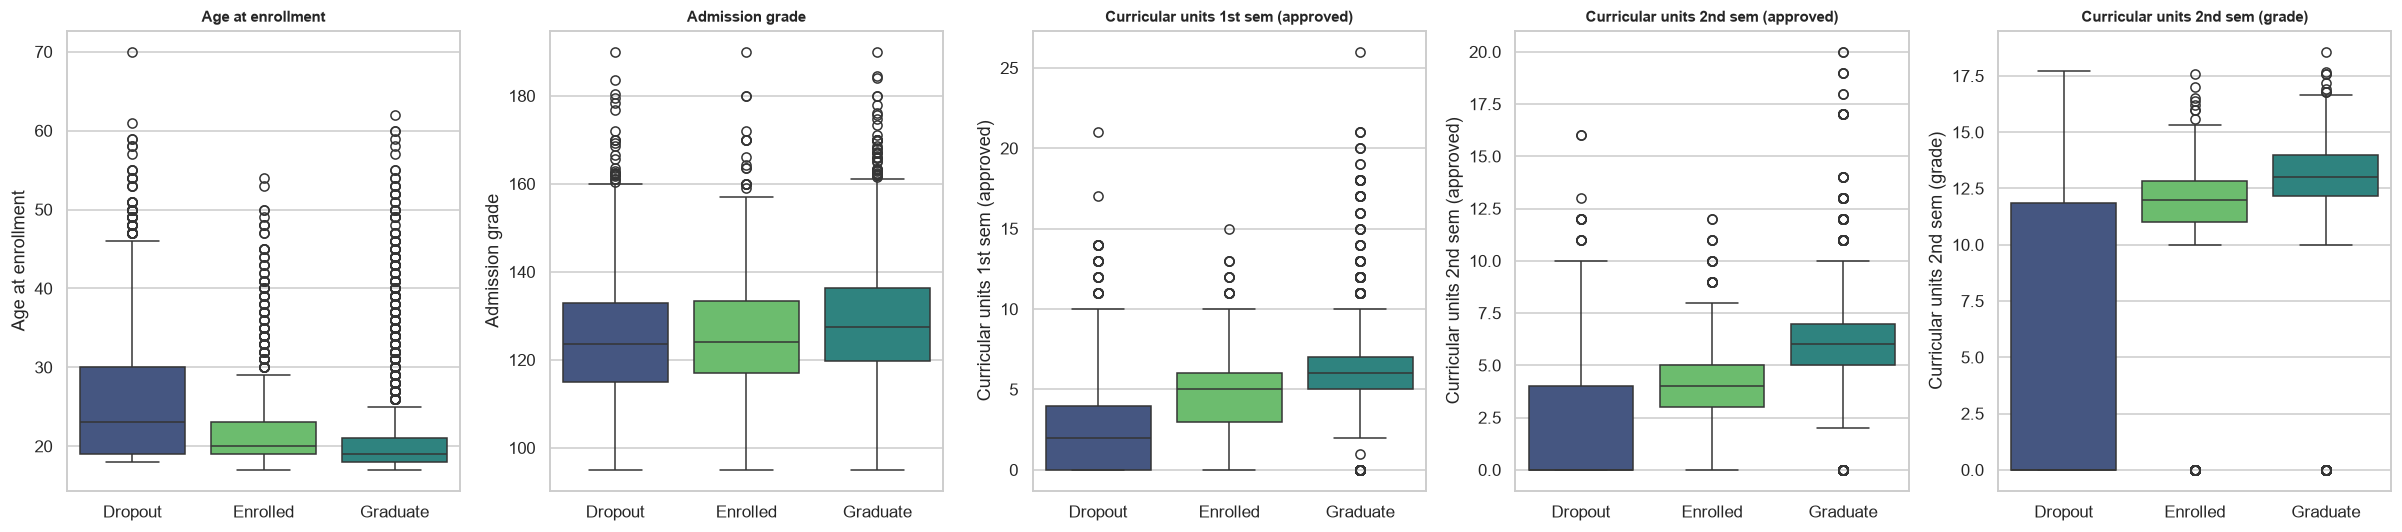

Figura guardada en: D:\_Dev\Projects\DefenzaGrado\outputs\figuras\03_comparacion_por_clase.png


In [13]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# El orden es fundamental para ver la progresion academica
orden_target = ['Dropout', 'Enrolled', 'Graduate']

for ax, col in zip(axes, columnas_clave):
    sns.boxplot(data=df, x='Target', y=col, order=orden_target, palette='viridis', hue='Target', legend=False, ax=ax)
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('')

plt.tight_layout()
# Guardamos la figura 03
ruta_fig_03 = DIR_FIGURAS / '03_comparacion_por_clase.png'
plt.savefig(ruta_fig_03, dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {ruta_fig_03}")

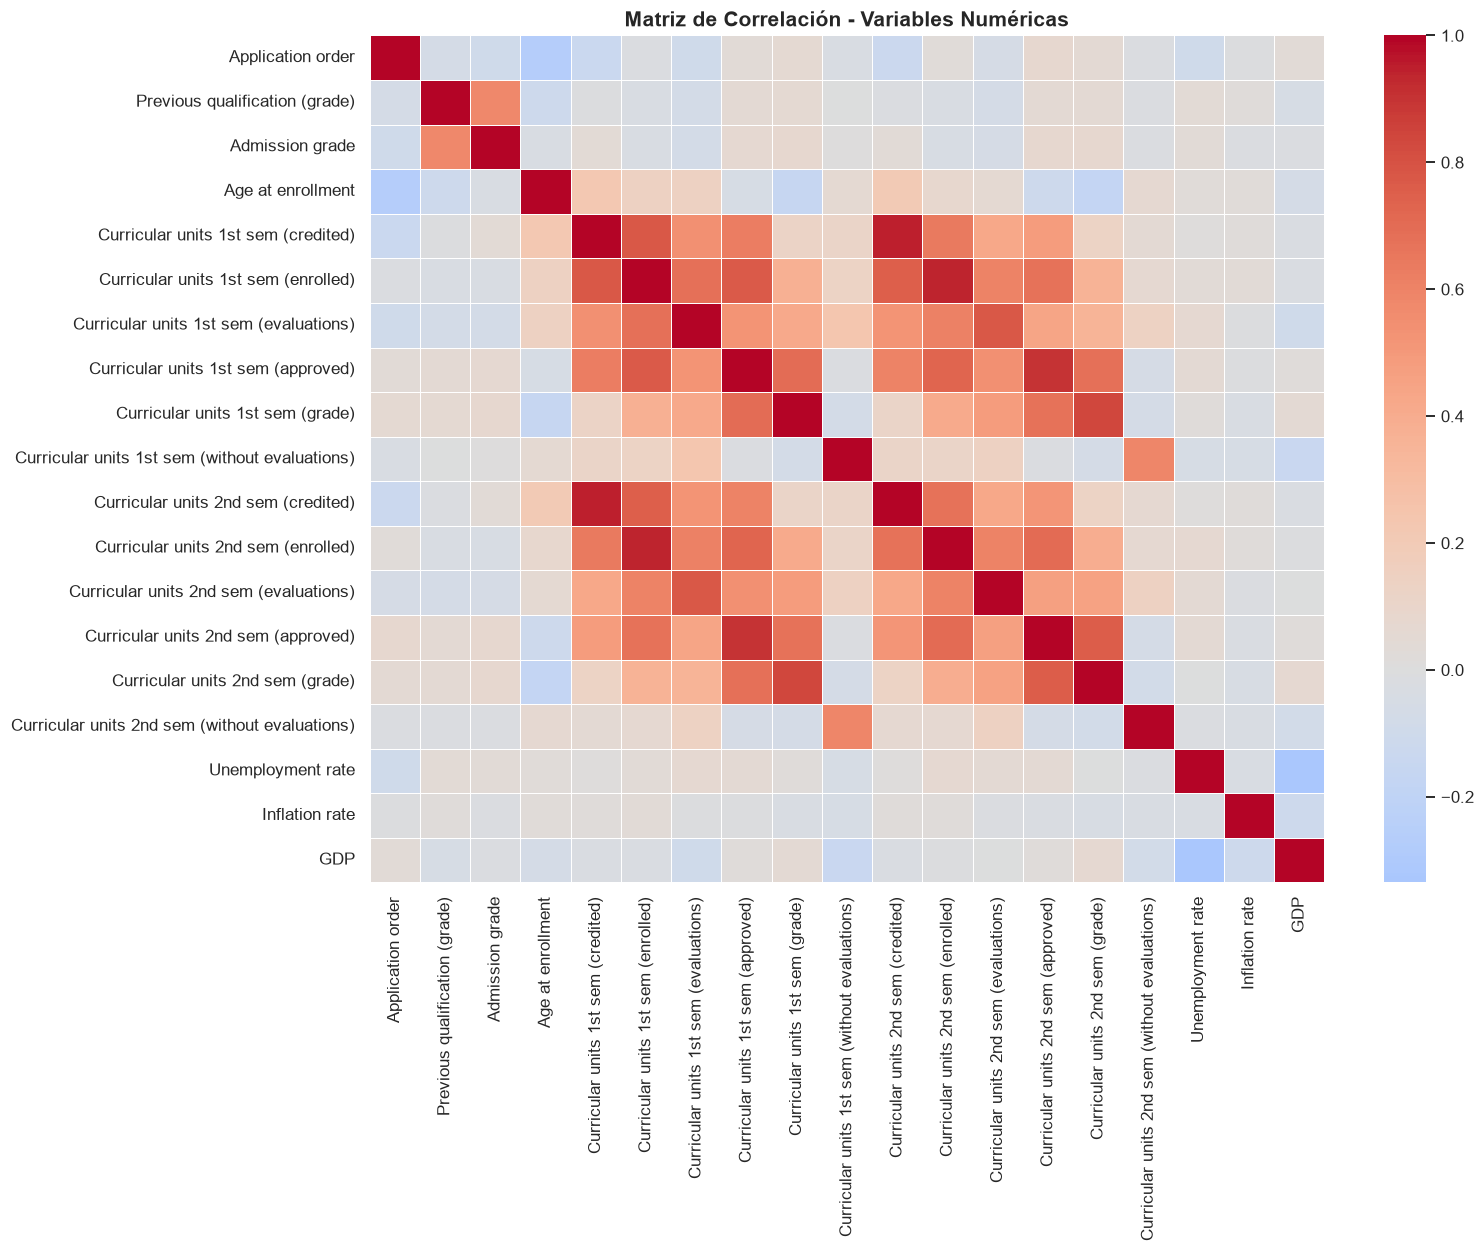

--- Posibles redundancias (Correlación > 0.8) ---
                                    Var1                                 Var2      Corr
86   Curricular units 1st sem (credited)  Curricular units 2nd sem (credited)  0.944811
194  Curricular units 2nd sem (credited)  Curricular units 1st sem (credited)  0.944811
214  Curricular units 2nd sem (enrolled)  Curricular units 1st sem (enrolled)  0.942627
106  Curricular units 1st sem (enrolled)  Curricular units 2nd sem (enrolled)  0.942627
254  Curricular units 2nd sem (approved)  Curricular units 1st sem (approved)  0.904002
146  Curricular units 1st sem (approved)  Curricular units 2nd sem (approved)  0.904002
166     Curricular units 1st sem (grade)     Curricular units 2nd sem (grade)  0.837170
274     Curricular units 2nd sem (grade)     Curricular units 1st sem (grade)  0.837170


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la correlación solo para las columnas numéricas
corr_matrix = df[COLUMNAS_NUMERICAS].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)

plt.title("Matriz de Correlación - Variables Numéricas", fontsize=14, weight='bold')

# Guardamos la figura
ruta_fig_04 = DIR_FIGURAS / '04_matriz_correlacion.png'
plt.savefig(ruta_fig_04, dpi=DPI_EXPORT)
plt.show()

# Identificar correlaciones altas (> 0.8)
print("--- Posibles redundancias (Correlación > 0.8) ---")
high_corr = corr_matrix.stack().reset_index()
high_corr.columns = ['Var1', 'Var2', 'Corr']
high_corr = high_corr[(high_corr['Corr'] > 0.8) & (high_corr['Var1'] != high_corr['Var2'])]
print(high_corr.sort_values(by='Corr', ascending=False))

In [15]:
# ============ 2.2 Redundancia exacta: dos variables que no aportan nada nuevo ============
#
# ===== POR QUE =====
# La matriz de correlacion de arriba solo mira variables NUMERICAS. No puede
# detectar que una variable BINARIA sea una funcion exacta de una CATEGORICA:
# la correlacion de Pearson no esta definida para eso de forma util.
#
# Y aca hay dos casos de identidad PERFECTA -- no correlacion alta, identidad:
# una variable se puede reconstruir al 100% desde otra. Verificarlo es barato y
# cambia como se leen los resultados.

print("Identidades exactas sobre las", len(df), "filas:\n")

# 1) International es exactamente "la nacionalidad no es la local"
ident_intl = (df['International'] == (df['Nacionality'] != 1).astype(int))
print(f"International == (Nacionality != 1)")
print(f"   coinciden {ident_intl.sum()} de {len(df)}  ->  {'IDENTIDAD EXACTA' if ident_intl.all() else 'no es exacta'}")

# 2) El turno queda determinado por la carrera
# int() para que la lista se imprima legible y no como [np.int64(8014), ...]
cursos_noche = sorted(int(c) for c in df.loc[df['Daytime/evening attendance'] == 0, 'Course'].unique())
ident_turno = (df['Daytime/evening attendance'] == (~df['Course'].isin(cursos_noche)).astype(int))
print(f"\nDaytime/evening attendance == (Course NO esta en {cursos_noche})")
print(f"   coinciden {ident_turno.sum()} de {len(df)}  ->  {'IDENTIDAD EXACTA' if ident_turno.all() else 'no es exacta'}")
print(f"   reparto: {int((df['Daytime/evening attendance']==1).sum())} diurno / "
      f"{int((df['Daytime/evening attendance']==0).sum())} nocturno")

print("""
QUE SIGNIFICA Y QUE SE DECIDE

1) 'Daytime/evening attendance' NO ES ASISTENCIA A CLASES. Es el turno en que
   cursa el estudiante, y ademas queda completamente determinado por la
   carrera: solo dos carreras se dictan de noche. O sea que la variable no
   aporta ninguna informacion propia -- es una etiqueta de 'Course'.

   Son DOS razones independientes para no apoyar ninguna politica en ella, y
   conviene tenerlas separadas: no mide lo que su nombre sugiere, y ademas es
   redundante.

2) 'International' es una recodificacion de 'Nacionality'. Misma situacion.

DECISION: se CONSERVAN las dos. Los motivos, en orden:

   - Random Forest tolera la redundancia sin degradarse: al elegir un
     subconjunto aleatorio de variables por nodo, si toma una de las dos
     copias el arbol parte igual. No hay inestabilidad de coeficientes como
     tendria una regresion lineal.
   - Quitarlas no cambiaria el resultado, pero SI romperia el contrato de 36
     variables que la API expone y valida con Pydantic.
   - Lo que si cambia es la LECTURA de la importancia: entre dos variables que
     dicen lo mismo, la importancia se reparte y ambas parecen menos
     importantes de lo que son. Es el mismo efecto que se documenta en 5.6
     para las materias aprobadas de 1er y 2do semestre (correlacion 0,916).

Detectar esto no era obligatorio. Poder explicar por que NO se elimina una
variable redundante vale mas que eliminarla sin pensarlo.""")


Identidades exactas sobre las 4424 filas:

International == (Nacionality != 1)
   coinciden 4424 de 4424  ->  IDENTIDAD EXACTA

Daytime/evening attendance == (Course NO esta en [8014, 9991])
   coinciden 4424 de 4424  ->  IDENTIDAD EXACTA
   reparto: 3941 diurno / 483 nocturno

QUE SIGNIFICA Y QUE SE DECIDE

1) 'Daytime/evening attendance' NO ES ASISTENCIA A CLASES. Es el turno en que
   cursa el estudiante, y ademas queda completamente determinado por la
   carrera: solo dos carreras se dictan de noche. O sea que la variable no
   aporta ninguna informacion propia -- es una etiqueta de 'Course'.

   Son DOS razones independientes para no apoyar ninguna politica en ella, y
   conviene tenerlas separadas: no mide lo que su nombre sugiere, y ademas es
   redundante.

2) 'International' es una recodificacion de 'Nacionality'. Misma situacion.

DECISION: se CONSERVAN las dos. Los motivos, en orden:

   - Random Forest tolera la redundancia sin degradarse: al elegir un
     subconjunto alea

In [16]:
# --- Chequeos finales de Calidad de Datos ---

# 1. Filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# 2. Verificar valores en 0 en columnas clave (Notas y Unidades Aprobadas)
# En este dataset, un 0 puede ser una nota real o la ausencia de evaluaciones.
columnas_notas = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']

print("\n--- Analisis de valores en cero ---")
for col in columnas_notas:
    conteo_ceros = (df[col] == 0).sum()
    porcentaje_ceros = (conteo_ceros / len(df)) * 100
    print(f"{col:35}: {conteo_ceros} ceros ({porcentaje_ceros:.2f}%)")

# 3. Edad al matricularse
print(f"\nRango de edad: {df['Age at enrollment'].min()} a {df['Age at enrollment'].max()} años")

Filas duplicadas: 0

--- Analisis de valores en cero ---
Curricular units 1st sem (grade)   : 718 ceros (16.23%)
Curricular units 2nd sem (grade)   : 870 ceros (19.67%)

Rango de edad: 17 a 70 años


## Fase 3 - Preparacion de los Datos

Aqui se transforma el dataset crudo en la matriz `X` y el vector `y` que consume
el modelo. Cada decision de esta fase es defendible o no: no hay una respuesta
"correcta" universal, hay una respuesta **justificada** para este caso.

In [17]:
# ============ 3.1 Definicion del target binario ============

# DECISION YA TOMADA (validada con los datos reales, ver 08-Defensa-Grado/
# Caso-IA-Desercion-Estudiantil.md): la clase 'Enrolled' (794 estudiantes) NO
# tiene desenlace confirmado todavia -- no se puede usar para entrenar ni para
# evaluar el modelo, porque no hay forma de saber si el numero real de aciertos
# es correcto. Se excluye del entrenamiento y se guarda aparte para usarla en la
# Fase 6 como poblacion de inferencia en vivo (la demo real: puntuar estudiantes
# actualmente matriculados, que es el caso de uso real del sistema).

# Resuelto en la celda siguiente: separacion en df_entrenamiento (3.630 filas,
# 1.421 Dropout + 2.209 Graduate) y df_enrolled (794), columna 'desertor'
# (1=Dropout, 0=Graduate), y separacion de X/y a partir de df_entrenamiento
# unicamente (sin tocar df_enrolled, para no filtrar la respuesta -- data
# leakage).

In [18]:
# 1. Separar el dataframe segun el estado del target
df_entrenamiento = df[df['Target'].isin(['Dropout', 'Graduate'])].copy()
df_enrolled = df[df['Target'] == 'Enrolled'].copy()

# 2. Crear la variable objetivo binaria 'desertor'
# 1 = Dropout (clase positiva), 0 = Graduate (clase negativa)
df_entrenamiento['desertor'] = df_entrenamiento['Target'].map({'Dropout': 1, 'Graduate': 0})

# 3. Separar X e y para el entrenamiento
X = df_entrenamiento.drop(columns=['Target', 'desertor'])
y = df_entrenamiento['desertor']

print(f"Filas para entrenamiento/prueba: {df_entrenamiento.shape[0]}")
print(f"Filas para inferencia futura (Enrolled): {df_enrolled.shape[0]}")
print("\nDistribucion de la nueva variable 'desertor':")
print(y.value_counts(normalize=True).map(lambda n: f'{n:.2%}') )

Filas para entrenamiento/prueba: 3630
Filas para inferencia futura (Enrolled): 794

Distribucion de la nueva variable 'desertor':
desertor
0    60.85%
1    39.15%
Name: proportion, dtype: str


In [19]:
# ============ 3.2 Valores nulos ============

# Resuelto en la celda siguiente: el dataset no reporta nulos declarados, y
# se deja escrito igual (que no haya nulos tambien es un hallazgo). No hace
# falta SimpleImputer/Pipeline de imputacion al no haber nulos que imputar.

In [20]:
from sklearn.impute import SimpleImputer

# Verificacion de nulos en el conjunto de entrenamiento
nulos_entrenamiento = X.isnull().sum().sum()

if nulos_entrenamiento == 0:
    print("No se detectaron valores nulos (NaN) en las variables predictoras.")
    print("Decision: No se requiere imputacion, pero se mantiene la logica de SimpleImputer en el pipeline final por robustez.")
else:
    print(f"Se detectaron {nulos_entrenamiento} valores nulos.")

# Nota para la defensa:
# Aunque no hay NaNs, los ceros en 'Curricular units 2nd sem (grade)'
# se consideran informacion valiosa del desempeño y no errores de carga.

No se detectaron valores nulos (NaN) en las variables predictoras.
Decision: No se requiere imputacion, pero se mantiene la logica de SimpleImputer en el pipeline final por robustez.


In [21]:
# ============ 3.3 Codificacion de variables categoricas ============

# Resuelto en la celda siguiente: One-Hot para las categoricas sin orden
# (Course, Marital Status, Nacionality, ...); las binarias 0/1 ya codificadas
# no necesitan transformacion; encoding aplicado con ColumnTransformer dentro
# del Pipeline para que sea reproducible en produccion (Fase 6).

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Definimos el transformador de columnas
# 'remainder=passthrough' asegura que las columnas que no transformamos (numéricas y binarias) se mantengan
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COLUMNAS_CATEGORICAS)
    ],
    remainder='passthrough'
)

# Nota para la defensa:
# Usamos OneHotEncoder para variables nominales para evitar sesgos de magnitud.
# handle_unknown='ignore' es vital para que el modelo no falle si en el futuro
# aparece una categoria nueva no vista en el entrenamiento.

print("Configuracion del preprocesador lista.")
print(f"Columnas a codificar: {len(COLUMNAS_CATEGORICAS)}")

Configuracion del preprocesador lista.
Columnas a codificar: 9


In [23]:
# ============ 3.4 Escalado ============
#
# ===== POR QUE =====
# DECISION: no se escala. Y saber por que NO se hace algo vale tanto como hacerlo.
#
# Random Forest toma decisiones del tipo "¿es esta variable <= umbral?". Le da
# exactamente igual que una variable vaya de 0 a 20 y otra de 0 a 200: el corte
# se busca en la escala propia de cada una. Escalar no cambiaria ni una sola
# particion del arbol.
#
# El escalado SI seria obligatorio si comparasemos contra modelos basados en
# distancia o en magnitud de coeficientes (KNN, SVM, regresion logistica).
# El modelo alternativo que se compara en 4.4 es XGBoost, que tambien parte por
# umbral -> tampoco lo necesita. Por eso el pipeline no lleva StandardScaler.

print("Sin escalado: Random Forest y XGBoost parten por umbral, la escala es irrelevante.")
print("Rangos muy distintos que conviven sin problema:")
for c in ['Admission grade', 'Curricular units 2nd sem (grade)', 'Age at enrollment', 'GDP']:
    print(f"  {c:38} {X[c].min():8.2f} .. {X[c].max():8.2f}")

Sin escalado: Random Forest y XGBoost parten por umbral, la escala es irrelevante.
Rangos muy distintos que conviven sin problema:
  Admission grade                           95.00 ..   190.00
  Curricular units 2nd sem (grade)           0.00 ..    18.57
  Age at enrollment                         17.00 ..    70.00
  GDP                                       -4.06 ..     3.51


In [24]:
# ============ 3.5 Division entrenamiento / prueba ============
#
# ===== POR QUE =====
# stratify=y es OBLIGATORIO con clases desbalanceadas. Sin el, un split al azar
# puede dejar 35% de desertores en train y 43% en test; entonces las metricas de
# test no miden al modelo, miden la suerte del sorteo.
#
# test_size=0.2 -> 726 filas de prueba, de las cuales ~284 son desertores reales.
# Ese numero importa: es la base sobre la que se traduce el criterio de exito a
# cantidades concretas (Recall>=80% -> detectar >=228 de esos 284).
#
# REGLA QUE NO SE ROMPE: el conjunto de prueba no se toca hasta la Fase 5.
# Todo el ajuste de hiperparametros se hace por validacion cruzada DENTRO del
# entrenamiento. Mirar test para elegir parametros es contaminarlo, y las
# metricas finales dejarian de ser una estimacion honesta.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)

print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")
print(f"\n{'':12} {'% desertor':>12} {'n desertor':>12}")
for nombre, yy in [('completo', y), ('train', y_train), ('test', y_test)]:
    print(f"{nombre:12} {yy.mean():>11.2%} {int(yy.sum()):>12}")

print(f"\nDesertores reales en test: {int(y_test.sum())}")
print(f"  Recall >= 80% exige detectar >= {int(np.ceil(0.8 * y_test.sum()))} de ellos "
      f"-> maximo {int(y_test.sum()) - int(np.ceil(0.8 * y_test.sum()))} Falsos Negativos")

Train: 2904 filas | Test: 726 filas

               % desertor   n desertor
completo          39.15%         1421
train             39.15%         1137
test              39.12%          284

Desertores reales en test: 284
  Recall >= 80% exige detectar >= 228 de ellos -> maximo 56 Falsos Negativos


In [25]:
# ============ 3.6 Manejo del desbalanceo: class_weight vs SMOTE ============
#
# ===== POR QUE =====
# Dos estrategias posibles, y en vez de opinar se MIDEN las dos:
#
# (a) class_weight='balanced': no toca los datos, cambia la funcion de costo.
#     Pondera cada clase inversamente a su frecuencia, asi equivocarse en un
#     desertor penaliza mas. Formula: peso = N / (n_clases * n_de_esa_clase).
#     Sin datos sinteticos, sin riesgo de fuga, un solo parametro.
#
# (b) SMOTE: genera ejemplos sinteticos de la minoritaria interpolando vecinos.
#     Puede subir el recall, pero INVENTA observaciones que no existieron.
#
# EL ERROR QUE HAY QUE SABER EXPLICAR (blanco tipico de tribunal): aplicar SMOTE
# ANTES del split. Si se hace, un punto sintetico derivado de un estudiante que
# quedara en test entra al entrenamiento -> se evalua contra informacion ya
# vista y las metricas salen infladas. Por eso SMOTE va DENTRO del Pipeline de
# imblearn, que lo aplica solo al fold de entrenamiento en cada iteracion del CV.

from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
print("class_weight='balanced' calcula:")
print(f"  Graduate (0): {pesos[0]:.3f}")
print(f"  Dropout  (1): {pesos[1]:.3f}")
print(f"  -> equivocarse en un desertor pesa {pesos[1]/pesos[0]:.2f}x mas durante el entrenamiento")

n_min, n_may = int(y_train.sum()), int((y_train == 0).sum())
print(f"\nSi en cambio se igualaran las clases con SMOTE:")
print(f"  habria que generar {n_may - n_min} estudiantes sinteticos")
print(f"  el set de entrenamiento pasaria de {len(y_train)} a {n_may * 2} filas")

class_weight='balanced' calcula:
  Graduate (0): 0.822
  Dropout  (1): 1.277
  -> equivocarse en un desertor pesa 1.55x mas durante el entrenamiento

Si en cambio se igualaran las clases con SMOTE:
  habria que generar 630 estudiantes sinteticos
  el set de entrenamiento pasaria de 2904 a 3534 filas


In [26]:
# --- Comparacion MEDIDA: class_weight vs SMOTE (ambas por validacion cruzada) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline as PipelineSk
from imblearn.pipeline import Pipeline as PipelineImb
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
METRICAS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


def evaluar(pipeline, nombre, X_=None, y_=None):
    """Corre CV y devuelve una fila con media +/- desviacion de cada metrica."""
    X_ = X_train if X_ is None else X_
    y_ = y_train if y_ is None else y_
    res = cross_validate(pipeline, X_, y_, cv=cv, scoring=METRICAS, n_jobs=-1)
    fila = {'estrategia': nombre}
    for m in METRICAS:
        fila[m] = res[f'test_{m}'].mean()
        fila[f'{m}_std'] = res[f'test_{m}'].std()
    return fila


rf_base = dict(n_estimators=200, random_state=SEMILLA, n_jobs=-1)

pipe_weight = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(class_weight='balanced', **rf_base)),
])

pipe_smote = PipelineImb([
    ('prep', preprocesador),
    ('smote', SMOTE(random_state=SEMILLA)),   # solo se aplica al fold de train
    ('clf', RandomForestClassifier(**rf_base)),
])

pipe_nada = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(**rf_base)),
])

filas = [
    evaluar(pipe_nada, 'sin tratamiento'),
    evaluar(pipe_weight, "class_weight='balanced'"),
    evaluar(pipe_smote, 'SMOTE'),
]
comparativa_desbalanceo = pd.DataFrame(filas).set_index('estrategia')
print("Validacion cruzada 5-fold sobre el conjunto de ENTRENAMIENTO:\n")
print(comparativa_desbalanceo[METRICAS].round(4).to_string())
print("\nDesviacion estandar del recall entre pliegues (estabilidad):")
print(comparativa_desbalanceo['recall_std'].round(4).to_string())

Validacion cruzada 5-fold sobre el conjunto de ENTRENAMIENTO:

                         accuracy  precision  recall      f1  roc_auc
estrategia                                                           
sin tratamiento            0.8981     0.9227  0.8074  0.8611   0.9447
class_weight='balanced'    0.8963     0.8968  0.8311  0.8627   0.9443
SMOTE                      0.9015     0.9159  0.8241  0.8675   0.9439

Desviacion estandar del recall entre pliegues (estabilidad):
estrategia
sin tratamiento            0.0180
class_weight='balanced'    0.0087
SMOTE                      0.0190


In [27]:
# ============ 3.7 One-hot vs enteros nativos ============
#
# ===== POR QUE =====
# Random Forest tolera categoricas como enteros: cada arbol solo corta por
# umbral, no asume que 9500 > 33 signifique algo real en magnitud. Entonces el
# one-hot de 3.3 (que infla a ~220 columnas para 3.630 filas) es una decision
# discutible, no una obligacion.
#
# En vez de defenderla con teoria, se mide: mismo modelo, mismo CV, mismos folds,
# cambiando solo el preprocesamiento. Sea cual sea el resultado, la respuesta al
# tribunal deja de ser "porque es la buena practica" y pasa a ser un numero.

# El one-hot no esta cuantificado en la celda 3.3, se calcula aca:
n_cols_onehot = len(preprocesador.fit(X).get_feature_names_out())
print(f"Columnas tras one-hot: {n_cols_onehot} (originales: {X.shape[1]})")

pipe_onehot = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(class_weight='balanced', **rf_base)),
])

# 'passthrough' = sin transformar nada: las categoricas entran como enteros
pipe_nativo = PipelineSk([
    ('clf', RandomForestClassifier(class_weight='balanced', **rf_base)),
])

comparativa_encoding = pd.DataFrame([
    evaluar(pipe_onehot, f'one-hot ({n_cols_onehot} columnas)'),
    evaluar(pipe_nativo, f'enteros nativos ({X.shape[1]} columnas)'),
]).set_index('estrategia')

print("Validacion cruzada 5-fold, unica diferencia = el encoding:\n")
print(comparativa_encoding[METRICAS].round(4).to_string())

dif_recall = (comparativa_encoding.loc[f'one-hot ({n_cols_onehot} columnas)', 'recall']
              - comparativa_encoding.loc[f'enteros nativos ({X.shape[1]} columnas)', 'recall'])
print(f"\nDiferencia de recall (one-hot - nativo): {dif_recall:+.4f}")
print("Si la diferencia es despreciable, el argumento defendible es que el one-hot")
print("se mantiene por correccion conceptual (no imponer orden falso), no por ganancia.")

Columnas tras one-hot: 238 (originales: 36)


Validacion cruzada 5-fold, unica diferencia = el encoding:

                               accuracy  precision  recall      f1  roc_auc
estrategia                                                                 
one-hot (238 columnas)           0.8963     0.8968  0.8311  0.8627   0.9443
enteros nativos (36 columnas)    0.8963     0.8985  0.8294  0.8625   0.9464

Diferencia de recall (one-hot - nativo): +0.0018
Si la diferencia es despreciable, el argumento defendible es que el one-hot
se mantiene por correccion conceptual (no imponer orden falso), no por ganancia.


## Fase 4 - Modelado

Random Forest es el modelo exigido por el caso. Se entrena una linea base, se
valida con `StratifiedKFold` y recien despues se ajustan los hiperparametros.

In [28]:
# ============ 4.1 Linea base y piso absoluto ============
#
# ===== POR QUE =====
# Dos puntos de comparacion, sin los cuales cualquier metrica final no significa nada:
#
# 1. DummyClassifier('most_frequent'): predice siempre "no desertor". Es el piso
#    absoluto. Su accuracy va a ser ~61% -- alta y completamente inutil, porque su
#    recall es 0: no detecta ni un solo desertor. Es LA demostracion de por que
#    accuracy es una metrica trampa en este problema y por que se prioriza recall.
#
# 2. Random Forest con parametros por defecto: la linea base real. Si el modelo
#    ajustado de 4.3 no le gana a esto, todo el ajuste fue tiempo perdido.

from sklearn.dummy import DummyClassifier

pipe_dummy = PipelineSk([
    ('clf', DummyClassifier(strategy='most_frequent')),
])

pipe_rf_default = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(random_state=SEMILLA, n_jobs=-1)),
])

comparativa_base = pd.DataFrame([
    evaluar(pipe_dummy, 'Dummy (siempre "no desertor")'),
    evaluar(pipe_rf_default, 'RF por defecto'),
    evaluar(pipe_weight, "RF + class_weight='balanced'"),
]).set_index('estrategia')

print(comparativa_base[METRICAS].round(4).to_string())
print("\nLeer la fila del Dummy: accuracy alta, recall 0. Ese contraste es el")
print("argumento de por que el criterio de exito del caso se fija en Recall.")

                               accuracy  precision  recall      f1  roc_auc
estrategia                                                                 
Dummy (siempre "no desertor")    0.6085     0.0000  0.0000  0.0000   0.5000
RF por defecto                   0.9001     0.9319  0.8039  0.8630   0.9431
RF + class_weight='balanced'     0.8963     0.8968  0.8311  0.8627   0.9443

Leer la fila del Dummy: accuracy alta, recall 0. Ese contraste es el
argumento de por que el criterio de exito del caso se fija en Recall.


In [29]:
# ============ 4.2 Validacion cruzada estratificada ============
#
# ===== POR QUE =====
# StratifiedKFold conserva la proporcion de desertores en CADA pliegue. Con
# KFold comun, un pliegue podria quedar con 30% de desertores y otro con 45%:
# la varianza reportada mediria el desbalance del sorteo, no la estabilidad del
# modelo.
#
# k=5 es el valor que pide el caso. Con 2.904 filas de entrenamiento da pliegues
# de ~581 filas -- suficiente para que cada metrica sea estable.
#
# Se reporta media +/- desviacion, no solo media: un modelo con recall 0.82+-0.02
# es confiable; uno con 0.82+-0.11 es una moneda al aire que promedio bien.

for i, (idx_tr, idx_va) in enumerate(cv.split(X_train, y_train), 1):
    y_va = y_train.iloc[idx_va]
    print(f"Pliegue {i}: {len(idx_va)} filas de validacion | "
          f"desertores {int(y_va.sum())} ({y_va.mean():.2%}) | "
          f"entrenamiento {len(idx_tr)}")

print("\nMetricas del modelo con class_weight (media +/- desviacion entre pliegues):")
fila = comparativa_base.loc["RF + class_weight='balanced'"]
for m in METRICAS:
    print(f"  {m:10} {fila[m]:.4f} +/- {fila[f'{m}_std']:.4f}")

Pliegue 1: 581 filas de validacion | desertores 228 (39.24%) | entrenamiento 2323
Pliegue 2: 581 filas de validacion | desertores 228 (39.24%) | entrenamiento 2323
Pliegue 3: 581 filas de validacion | desertores 227 (39.07%) | entrenamiento 2323
Pliegue 4: 581 filas de validacion | desertores 227 (39.07%) | entrenamiento 2323
Pliegue 5: 580 filas de validacion | desertores 227 (39.14%) | entrenamiento 2324

Metricas del modelo con class_weight (media +/- desviacion entre pliegues):
  accuracy   0.8963 +/- 0.0086
  precision  0.8968 +/- 0.0157
  recall     0.8311 +/- 0.0087
  f1         0.8627 +/- 0.0110
  roc_auc    0.9443 +/- 0.0086


In [30]:
# ============ 4.3 Ajuste de hiperparametros ============
#
# ===== POR QUE =====
# Espacio de busqueda EXACTO del enunciado. Que controla cada uno:
#   - n_estimators      : cuantos arboles votan. Mas = mas estable y mas lento.
#                         NO causa sobreajuste (es lo contrario a lo intuitivo:
#                         promediar mas arboles reduce varianza).
#   - max_depth         : cuanto crece cada arbol. Mas profundo = mas memoriza.
#   - min_samples_split : minimo de muestras para partir un nodo.
#   - min_samples_leaf  : minimo de muestras en una hoja.
#     Los dos ultimos son frenos: al subirlos, el arbol generaliza mas.
#
# GridSearchCV vs RandomizedSearchCV: se calcula abajo el tamano del grid
# completo. Ese numero (multiplicado por 5 folds) es el argumento para elegir
# busqueda aleatoria -- Bergstra & Bengio (2012) mostraron que muestrear al azar
# encuentra configuraciones equivalentes con una fraccion del costo, porque
# pocos hiperparametros dominan el resultado.
#
# scoring='recall', NO 'accuracy': la busqueda tiene que optimizar la misma
# metrica que declaramos como criterio de exito en la Fase 1. Optimizar accuracy
# aqui y despues reportar recall seria incoherente.

from sklearn.model_selection import RandomizedSearchCV

espacio = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': [5, 8, 10, 12, 15, 20, None],
    'clf__min_samples_split': [2, 4, 6, 8, 10],
    'clf__min_samples_leaf': [1, 2, 3, 4, 5],
}

combinaciones = np.prod([len(v) for v in espacio.values()])
N_ITER = 40
print(f"Grid completo      : {combinaciones} combinaciones x 5 folds = "
      f"{combinaciones * 5} entrenamientos")
print(f"Busqueda aleatoria : {N_ITER} combinaciones x 5 folds = {N_ITER * 5} entrenamientos")
print(f"Reduccion          : {100 * (1 - N_ITER / combinaciones):.1f}% menos de computo\n")

busqueda = RandomizedSearchCV(
    estimator=pipe_weight,
    param_distributions=espacio,
    n_iter=N_ITER,
    scoring='recall',
    cv=cv,
    random_state=SEMILLA,
    n_jobs=-1,
    verbose=0,
)
busqueda.fit(X_train, y_train)

modelo_final = busqueda.best_estimator_
print("Mejores hiperparametros encontrados:")
for k, v in busqueda.best_params_.items():
    print(f"  {k.replace('clf__', ''):20} = {v}")
print(f"\nRecall en CV del mejor modelo: {busqueda.best_score_:.4f}")

Grid completo      : 875 combinaciones x 5 folds = 4375 entrenamientos
Busqueda aleatoria : 40 combinaciones x 5 folds = 200 entrenamientos
Reduccion          : 95.4% menos de computo



Mejores hiperparametros encontrados:
  n_estimators         = 100
  min_samples_split    = 6
  min_samples_leaf     = 3
  max_depth            = 20

Recall en CV del mejor modelo: 0.8443


In [31]:
# --- Ajustado vs linea base: ¿el ajuste sirvio de algo? ---
comparativa_ajuste = pd.DataFrame([
    evaluar(pipe_rf_default, 'RF por defecto'),
    evaluar(pipe_weight, "RF + class_weight (sin ajustar)"),
    evaluar(modelo_final, 'RF ajustado (RandomizedSearch)'),
]).set_index('estrategia')

print(comparativa_ajuste[METRICAS].round(4).to_string())

ganancia = (comparativa_ajuste.loc['RF ajustado (RandomizedSearch)', 'recall']
            - comparativa_ajuste.loc['RF por defecto', 'recall'])
print(f"\nGanancia de recall del ajuste sobre el default: {ganancia:+.4f}")

                                 accuracy  precision  recall      f1  roc_auc
estrategia                                                                   
RF por defecto                     0.9001     0.9319  0.8039  0.8630   0.9431
RF + class_weight (sin ajustar)    0.8963     0.8968  0.8311  0.8627   0.9443
RF ajustado (RandomizedSearch)     0.8943     0.8811  0.8443  0.8623   0.9434

Ganancia de recall del ajuste sobre el default: +0.0405


In [32]:
# ============ 4.4 Modelo alternativo (XGBoost) ============
#
# ===== POR QUE =====
# El caso EXIGE Random Forest, asi que XGBoost no lo reemplaza: es un contraste.
# Tener un competidor medido demuestra que la eleccion del modelo se verifico en
# vez de darse por sentada.
#
# Diferencia conceptual que conviene poder decir: Random Forest entrena arboles
# en PARALELO sobre muestras bootstrap y promedia (bagging, reduce varianza);
# XGBoost los entrena en SECUENCIA, cada uno corrigiendo el error del anterior
# (boosting, reduce sesgo). Aqui el equivalente de class_weight es
# scale_pos_weight.

from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()
pipe_xgb = PipelineSk([
    ('prep', preprocesador),
    ('clf', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=ratio, random_state=SEMILLA,
        eval_metric='logloss', n_jobs=-1,
    )),
])

comparativa_modelos = pd.DataFrame([
    evaluar(modelo_final, 'Random Forest ajustado'),
    evaluar(pipe_xgb, f'XGBoost (scale_pos_weight={ratio:.2f})'),
]).set_index('estrategia')

print(comparativa_modelos[METRICAS].round(4).to_string())
print("\nSe reporta el contraste; el modelo entregado sigue siendo Random Forest")
print("por requisito explicito del caso.")

                                 accuracy  precision  recall      f1  roc_auc
estrategia                                                                   
Random Forest ajustado             0.8943     0.8811  0.8443  0.8623   0.9434
XGBoost (scale_pos_weight=1.55)    0.9015     0.9087  0.8320  0.8686   0.9442

Se reporta el contraste; el modelo entregado sigue siendo Random Forest
por requisito explicito del caso.


In [33]:
# ============ 4.5 Comparacion entre familias de modelos ============
#
# ===== POR QUE =====
# 4.4 comparo Random Forest contra XGBoost, pero los dos son ensambles de
# arboles: es comparar dos variantes de la misma idea. Para sostener que Random
# Forest es una eleccion correcta -- y no solo una imposicion del enunciado --
# hay que medirlo contra familias DISTINTAS de modelos:
#
#   - Regresion logistica: modelo lineal. Es el estandar historico en la
#     literatura de desercion universitaria y el mas interpretable de todos
#     (cada variable tiene un coeficiente con signo y magnitud).
#   - Arbol de decision simple: el mismo tipo de modelo pero SIN el ensamble.
#     La distancia entre este y Random Forest mide exactamente que aporta el
#     bagging, que es el corazon conceptual del modelo elegido.
#   - KNN: modelo basado en distancia, sin ninguna nocion de particion.
#
# DETALLE TECNICO QUE IMPORTA: la regresion logistica y KNN SI necesitan
# escalado -- una usa la magnitud de los coeficientes, el otro distancias
# euclideas. Compararlos sin escalar seria hacerlos perder por una decision
# nuestra y no por su merito, y la comparacion no probaria nada. Por eso cada
# uno lleva su propio StandardScaler, que es justamente lo que 3.4 explico que
# Random Forest no necesita.
#
# Todos se evaluan con los MISMOS pliegues (el objeto `cv` con semilla fija),
# sobre el MISMO conjunto de entrenamiento. Lo unico que cambia es el modelo.

import time

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


def pipe_con_escalado(clf):
    """Pipeline para modelos sensibles a la escala de las variables."""
    return PipelineSk([
        ('prep', preprocesador),
        ('escala', StandardScaler()),
        ('clf', clf),
    ])


candidatos = {
    'Dummy (piso absoluto)': PipelineSk([
        ('clf', DummyClassifier(strategy='most_frequent')),
    ]),
    'Regresion logistica': pipe_con_escalado(
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEMILLA)
    ),
    'KNN (k=15)': pipe_con_escalado(KNeighborsClassifier(n_neighbors=15)),
    'Arbol de decision (1 solo)': PipelineSk([
        ('prep', preprocesador),
        ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=SEMILLA)),
    ]),
    'Random Forest ajustado': modelo_final,
    'XGBoost': pipe_xgb,
}

filas, segundos = [], {}
for nombre, pipe in candidatos.items():
    t0 = time.perf_counter()
    filas.append(evaluar(pipe, nombre))
    segundos[nombre] = time.perf_counter() - t0

comparativa_familias = pd.DataFrame(filas).set_index('estrategia')
comparativa_familias['seg_cv'] = pd.Series(segundos)

print("Validacion cruzada 5-fold, mismos pliegues para todos los modelos:\n")
print(comparativa_familias[METRICAS + ['seg_cv']].round(4).to_string())

print("\nRecall con su dispersion entre pliegues (lo que fija el criterio de exito):")
for nombre in comparativa_familias.index:
    f = comparativa_familias.loc[nombre]
    print(f"  {nombre:28} {f['recall']:.4f} +/- {f['recall_std']:.4f}")

mejor = comparativa_familias.drop('Dummy (piso absoluto)')['recall'].idxmax()
print(f"\nMejor recall: {mejor}")
print("Que un modelo encabece la tabla no alcanza para elegirlo: hay que ver si")
print("la diferencia sobrevive a la variacion entre pliegues. Eso se mide en 4.6.")


Validacion cruzada 5-fold, mismos pliegues para todos los modelos:

                            accuracy  precision  recall      f1  roc_auc  seg_cv
estrategia                                                                      
Dummy (piso absoluto)         0.6085     0.0000  0.0000  0.0000   0.5000  0.0369
Regresion logistica           0.8871     0.8608  0.8496  0.8549   0.9375  0.1862
KNN (k=15)                    0.7493     0.8290  0.4538  0.5858   0.8408  0.2907
Arbol de decision (1 solo)    0.8502     0.8039  0.8179  0.8105   0.8445  0.1235
Random Forest ajustado        0.8943     0.8811  0.8443  0.8623   0.9434  0.5353
XGBoost                       0.9015     0.9087  0.8320  0.8686   0.9442  1.2278

Recall con su dispersion entre pliegues (lo que fija el criterio de exito):
  Dummy (piso absoluto)        0.0000 +/- 0.0000
  Regresion logistica          0.8496 +/- 0.0167
  KNN (k=15)                   0.4538 +/- 0.0326
  Arbol de decision (1 solo)   0.8179 +/- 0.0169
  Random Fo

In [34]:
# ============ 4.6 La diferencia entre modelos, ¿es real o es ruido? ============
#
# ===== POR QUE =====
# "Lo que no se mide no se puede mejorar" -- pero medir mal es peor que no
# medir. Una tabla de promedios invita a un error concreto: leer que un modelo
# saca 0.8443 y otro 0.8320 y concluir que el primero es mejor, cuando la
# diferencia puede ser menor que lo que cada modelo varia de un pliegue a otro.
#
# Como los seis modelos se evaluaron sobre LOS MISMOS pliegues, las diferencias
# se pueden comparar de a pares: para cada pliegue, cuanto saco Random Forest
# menos cuanto saco el competidor. Si esas cinco diferencias son del mismo signo
# y grandes respecto de su dispersion, la ventaja es real; si cambian de signo,
# es ruido.
#
# SE COMPARAN DOS METRICAS, y la distincion es el argumento central:
#
#   - recall @ 0.5: cuantos desertores detecta CON EL UMBRAL FIJO en 0.5.
#   - ROC-AUC: la capacidad de ORDENAR bien, sin depender de ningun umbral.
#
# Para este sistema la segunda es la que decide. El producto no es una
# clasificacion binaria: es una lista priorizada que Bienestar recorre de arriba
# hacia abajo hasta agotar su capacidad, y el umbral se mueve desde la interfaz
# segun cuantas tutorias haya. Un modelo que ordena mejor sirve mejor en TODOS
# los umbrales; comparar solo el recall a 0.5 mide el desempeno en un unico
# punto de operacion que ademas no es fijo.
#
# HONESTIDAD METODOLOGICA: se reporta el p-valor de una prueba t pareada, con
# una advertencia que conviene decir antes de que la pregunten. Los pliegues de
# una validacion cruzada comparten datos de entrenamiento, asi que NO son
# independientes, y la prueba t asume que si. Dietterich (1998) mostro que eso
# infla los falsos positivos. Por eso el p-valor se usa como INDICIO y la
# decision se apoya tambien en el signo consistente entre pliegues y en la
# magnitud de la diferencia frente a su dispersion.

from scipy import stats
from sklearn.model_selection import cross_val_score


def por_pliegue(pipe, metrica):
    """Puntaje en cada uno de los 5 pliegues (los mismos para todos)."""
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=metrica, n_jobs=-1)


def comparar(metrica):
    """Random Forest contra cada competidor, en la metrica pedida."""
    base = por_pliegue(modelo_final, metrica)
    filas = []
    for nombre, pipe in candidatos.items():
        if nombre in ('Random Forest ajustado', 'Dummy (piso absoluto)'):
            continue
        rival = por_pliegue(pipe, metrica)
        dif = base - rival                      # positivo = gana Random Forest
        _, p = stats.ttest_rel(base, rival)
        filas.append({
            'competidor': nombre,
            f'{metrica}_rival': rival.mean(),
            'dif_media': dif.mean(),
            'dif_std': dif.std(ddof=1),
            'p_valor': p,
            'pliegues_a_favor': int((dif > 0).sum()),
        })
    return base, pd.DataFrame(filas).set_index('competidor')


def veredicto(dif, p, alfa=0.05):
    if p >= alfa:
        return 'empate (no se distingue del ruido)'
    return 'gana Random Forest' if dif > 0 else 'gana el competidor'


resultados = {}
for metrica in ('recall', 'roc_auc'):
    base, tabla = comparar(metrica)
    tabla['veredicto'] = [veredicto(f.dif_media, f.p_valor) for f in tabla.itertuples()]
    resultados[metrica] = tabla
    print(f"=== {metrica.upper()} ===")
    print(f"Random Forest por pliegue: {np.round(base, 4)}  "
          f"(media {base.mean():.4f} +/- {base.std():.4f})\n")
    print(tabla.round(4).to_string())
    print()

# --- Conclusion generada desde los numeros, no escrita de antemano ---
# Un veredicto fijo al lado de una tabla calculada es una trampa: si cambian los
# datos o la semilla, el texto afirma algo que su propia tabla desmiente.
rec, auc = resultados['recall'], resultados['roc_auc']

print("=" * 72)
print("LECTURA (generada a partir de las tablas de arriba)\n")

empates_rec = list(rec.index[rec['veredicto'].str.startswith('empate')])
gana_rec = list(rec.index[rec['veredicto'] == 'gana Random Forest'])
pierde_rec = list(rec.index[rec['veredicto'] == 'gana el competidor'])

print("1) Con el umbral fijo en 0.5 (recall):")
if gana_rec:
    print(f"   Random Forest supera de forma consistente a: {', '.join(gana_rec)}.")
if empates_rec:
    print(f"   Empata (la diferencia no se distingue del ruido) con: {', '.join(empates_rec)}.")
if pierde_rec:
    print(f"   Queda por debajo de: {', '.join(pierde_rec)}.")

gana_auc = list(auc.index[auc['veredicto'] == 'gana Random Forest'])
empates_auc = list(auc.index[auc['veredicto'].str.startswith('empate')])
pierde_auc = list(auc.index[auc['veredicto'] == 'gana el competidor'])

print("\n2) Ordenando la poblacion, sin depender del umbral (ROC-AUC):")
if gana_auc:
    print(f"   Random Forest supera de forma consistente a: {', '.join(gana_auc)}.")
if empates_auc:
    print(f"   Empata con: {', '.join(empates_auc)}.")
if pierde_auc:
    print(f"   Queda por debajo de: {', '.join(pierde_auc)}.")

arbol = 'Arbol de decision (1 solo)'
salto = comparativa_familias.loc['Random Forest ajustado', 'roc_auc'] - \
        comparativa_familias.loc[arbol, 'roc_auc']
print(f"\n3) Lo que aporta el ensamble: contra un arbol individual, mismo tipo de")
print(f"   modelo y unica diferencia el bagging, el ROC-AUC sube {salto:+.4f}.")
print( "   Es la evidencia directa de que promediar arboles sobre muestras")
print( "   bootstrap reduce la varianza, que es el argumento teorico del modelo.")

print("""
QUE SE PUEDE AFIRMAR CON ESTO

El enunciado del caso exige Random Forest, pero eso no exime de justificarlo.
La comparacion no busca "ganarle a todos": busca saber si la exigencia coincide
con una eleccion razonable y en que condiciones.

Lo que hay que poder decir sin titubear:

- Si algun modelo empata en recall a 0.5, no alcanza para descartar Random
  Forest, porque el umbral 0.5 no es el punto de operacion del sistema: se
  mueve desde la interfaz segun la capacidad de tutorias del periodo. La
  metrica que corresponde comparar es la que no depende del umbral.

- El salto respecto del arbol individual es lo que hay que subrayar: no es
  "Random Forest es mejor porque si", es que el ensamble aporta una mejora
  medible sobre exactamente el mismo tipo de modelo.

- Donde el desempeno empata de verdad, el criterio pasa a ser operativo:
  cuantos hiperparametros hay que sostener, si el modelo entrega importancia de
  variables sin herramientas extra, y si el area de Bienestar puede auditar por
  que se llamo a un estudiante y no a otro. Elegir por interpretabilidad cuando
  el desempeno empata no es conformarse: es reconocer quien va a usar esto.

Referencia: Dietterich, T. (1998). Approximate Statistical Tests for Comparing
Supervised Classification Learning Algorithms. Neural Computation, 10(7),
1895-1923.
""")


=== RECALL ===
Random Forest por pliegue: [0.8377 0.8333 0.8502 0.8678 0.8326]  (media 0.8443 +/- 0.0133)

                            recall_rival  dif_media  dif_std  p_valor  pliegues_a_favor                           veredicto
competidor                                                                                                                 
Regresion logistica               0.8496    -0.0053   0.0140   0.4472                 2  empate (no se distingue del ruido)
KNN (k=15)                        0.4538     0.3906   0.0474   0.0001                 5                  gana Random Forest
Arbol de decision (1 solo)        0.8179     0.0264   0.0149   0.0167                 4                  gana Random Forest
XGBoost                           0.8320     0.0123   0.0072   0.0190                 5                  gana Random Forest



=== ROC_AUC ===
Random Forest por pliegue: [0.9347 0.9375 0.9386 0.9584 0.9477]  (media 0.9434 +/- 0.0087)

                            roc_auc_rival  dif_media  dif_std  p_valor  pliegues_a_favor                           veredicto
competidor                                                                                                                  
Regresion logistica                0.9375     0.0058   0.0072   0.1436                 3  empate (no se distingue del ruido)
KNN (k=15)                         0.8408     0.1026   0.0143   0.0001                 5                  gana Random Forest
Arbol de decision (1 solo)         0.8445     0.0989   0.0040   0.0000                 5                  gana Random Forest
XGBoost                            0.9442    -0.0008   0.0054   0.7509                 2  empate (no se distingue del ruido)

LECTURA (generada a partir de las tablas de arriba)

1) Con el umbral fijo en 0.5 (recall):
   Random Forest supera de forma consistente a: K

In [35]:
# ============ 4.7 Sensibilidad: que pasa si muevo cada hiperparametro ============
#
# ===== POR QUE =====
# La busqueda de 4.3 devolvio una configuracion ganadora, pero no explica NADA
# sobre por que esa y no otra. Si alguien pregunta "¿y si subis max_depth?", la
# respuesta "aumenta el sobreajuste" es de manual: no dice cuanto, ni si en
# estos datos siquiera pasa.
#
# LO QUE SE MIDE, Y POR QUE ASI: se barre un hiperparametro por vez dejando los
# demas en la configuracion ganadora, y se registran DOS curvas:
#
#   - entrenamiento: que tan bien le va sobre los datos que ya vio
#   - validacion cruzada: que tan bien le va sobre datos nuevos
#
# El sobreajuste NO se ve en la curva de validacion sola. Se ve en la BRECHA
# entre las dos. Un modelo que saca 1.00 en entrenamiento y 0.84 en validacion
# esta memorizando; uno que saca 0.86 y 0.84 esta generalizando. Por eso se
# reportan las dos y su diferencia, y no solo el puntaje final.
#
# validation_curve hace exactamente esto y devuelve ambas matrices. Se usa el
# MISMO objeto `cv` que el resto del notebook, asi que los pliegues son los
# mismos y los numeros son comparables con todo lo anterior.
#
# Se mide en RECALL, que es el criterio de exito declarado en la Fase 1.

from sklearn.base import clone
from sklearn.model_selection import validation_curve

# La configuracion ganadora de 4.3, que es el punto de referencia de todas las curvas.
GANADORES = {
    'clf__n_estimators': 100,
    'clf__max_depth': 20,
    'clf__min_samples_split': 6,
    'clf__min_samples_leaf': 3,
    'clf__max_features': 'sqrt',        # default de sklearn; la busqueda no lo movio
    'clf__class_weight': 'balanced',    # decision de 3.6, tampoco se busco
}

BARRIDOS = [
    ('clf__max_depth',         [2, 3, 5, 8, 12, 20, None]),
    ('clf__n_estimators',      [10, 25, 50, 100, 200, 500]),
    ('clf__min_samples_leaf',  [1, 2, 3, 5, 10, 20]),
    ('clf__min_samples_split', [2, 4, 6, 10, 20, 40]),
    ('clf__max_features',      ['sqrt', 'log2', 0.3, 0.6, 1.0]),
    ('clf__class_weight',      [None, 'balanced', 'balanced_subsample']),
]

# Base = pipeline con la configuracion ganadora. Cada barrido cambia UN parametro.
base = clone(pipe_weight).set_params(**GANADORES)

sensibilidad = {}
for parametro, valores in BARRIDOS:
    otros = {k: v for k, v in GANADORES.items() if k != parametro}
    tr, va = validation_curve(
        clone(base).set_params(**otros),
        X_train, y_train,
        param_name=parametro,
        param_range=valores,
        scoring='recall',
        cv=cv,
        n_jobs=-1,
    )
    corto = parametro.replace('clf__', '')
    sensibilidad[corto] = pd.DataFrame({
        'valor': [str(v) for v in valores],
        'recall_train': tr.mean(axis=1),
        'recall_cv': va.mean(axis=1),
        'cv_std': va.std(axis=1),
    }).assign(brecha=lambda d: d.recall_train - d.recall_cv).set_index('valor')

for corto, tabla in sensibilidad.items():
    elegido = str(GANADORES[f'clf__{corto}'])
    print(f"--- {corto}  (elegido: {elegido}) ---")
    print(tabla.round(4).to_string())
    print()

print("Como leer la columna 'brecha': recall en entrenamiento menos recall en")
print("validacion. Cuanto mas grande, mas esta memorizando el modelo en vez de")
print("aprender el patron. Es lo que hay que mirar, no el recall de train solo.")


--- max_depth  (elegido: 20) ---
       recall_train  recall_cv  cv_std  brecha
valor                                         
2            0.8023     0.8013  0.0119  0.0011
3            0.8182     0.8188  0.0090 -0.0007
5            0.8382     0.8232  0.0147  0.0149
8            0.8676     0.8294  0.0140  0.0382
12           0.8940     0.8373  0.0131  0.0567
20           0.9158     0.8443  0.0133  0.0714
None         0.9193     0.8417  0.0135  0.0776

--- n_estimators  (elegido: 100) ---
       recall_train  recall_cv  cv_std  brecha
valor                                         
10           0.9096     0.8180  0.0181  0.0917
25           0.9129     0.8382  0.0179  0.0747
50           0.9134     0.8399  0.0167  0.0734
100          0.9158     0.8443  0.0133  0.0714
200          0.9164     0.8443  0.0119  0.0721
500          0.9171     0.8426  0.0108  0.0745

--- min_samples_leaf  (elegido: 3) ---
       recall_train  recall_cv  cv_std  brecha
valor                                      

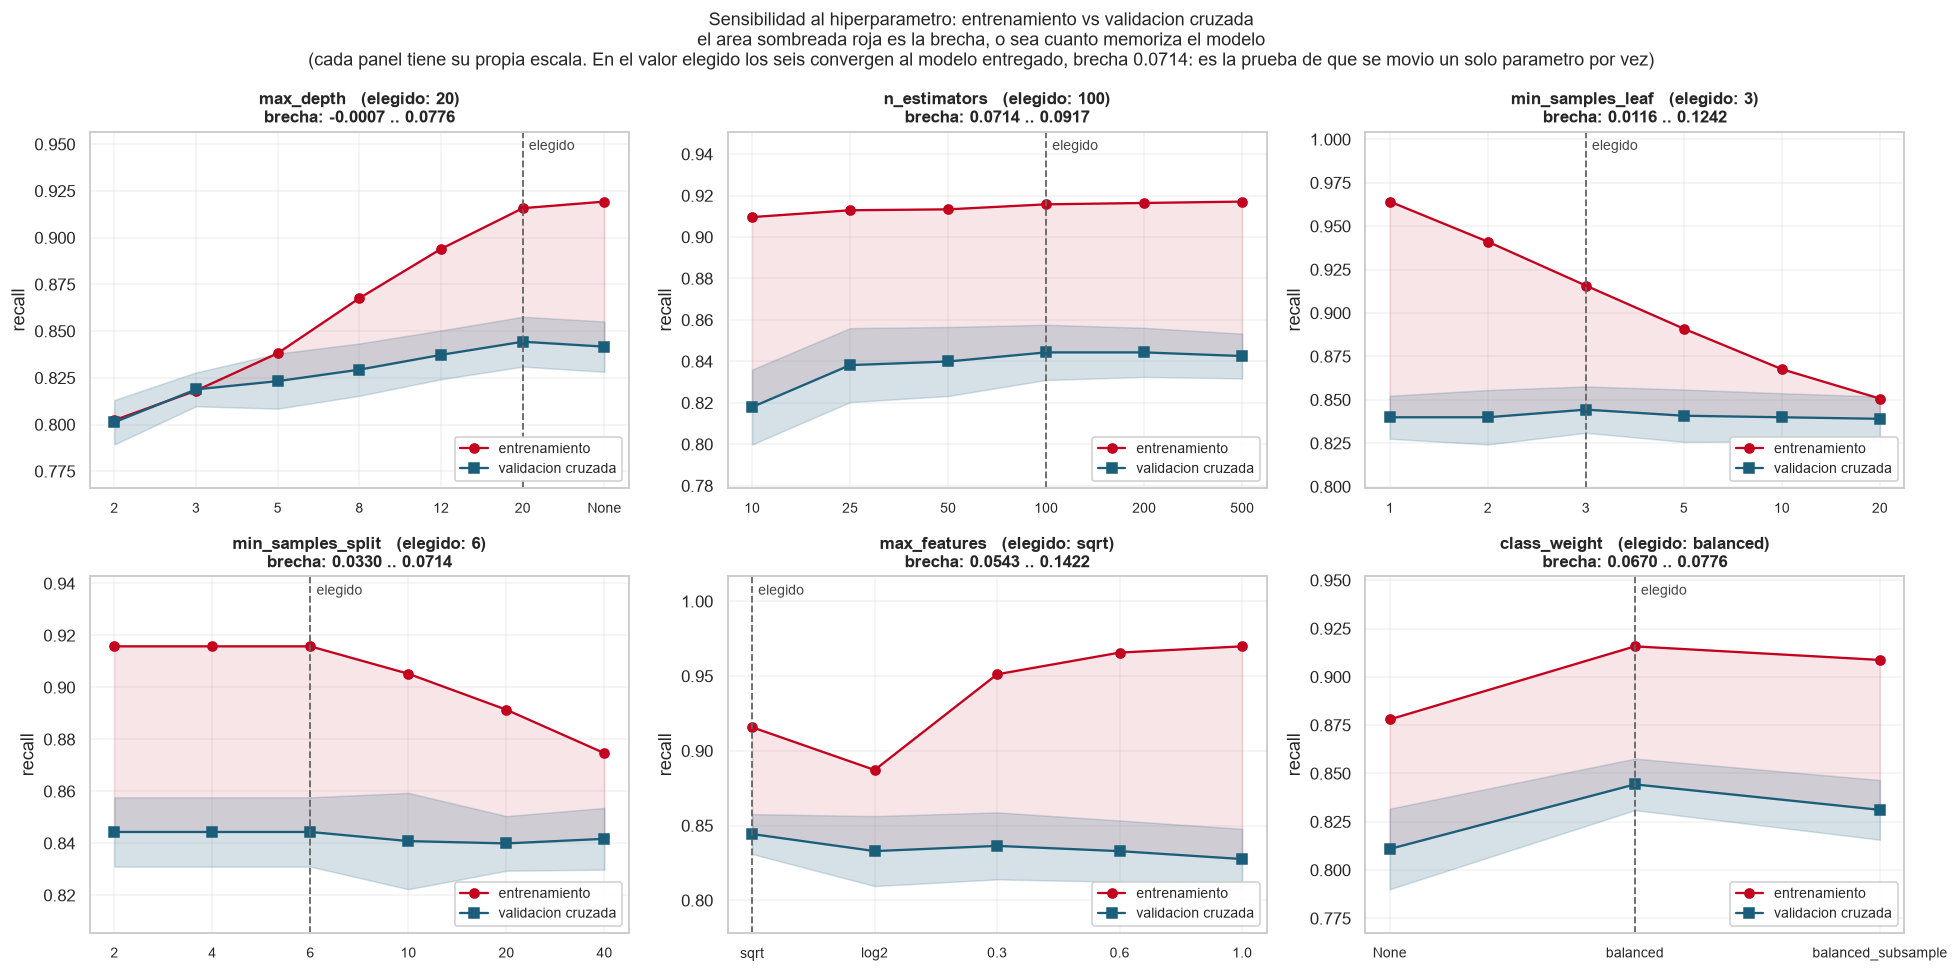

Figura guardada en ..\outputs\figuras\sensibilidad_hiperparametros.png


In [36]:
# --- Figura: las seis curvas, entrenamiento contra validacion ---
#
# Un panel por hiperparametro. La linea de arriba es entrenamiento, la de abajo
# validacion cruzada, y el area sombreada entre ellas es la BRECHA: es,
# literalmente, cuanto esta memorizando el modelo.
#
# Cada panel ajusta su eje a sus propios datos. Con un eje comun de 0 a 1 las
# seis curvas quedan aplastadas arriba y la brecha -- que es todo el mensaje --
# no se distingue. El precio es que los paneles no son comparables entre si a
# ojo, y por eso cada uno lleva su escala a la vista.
#
# La linea vertical marca el valor que eligio RandomizedSearchCV, para poder
# responder "por que ese?" senalando la curva.
#
# NOTA: esta figura NO va al documento. Las figuras 01-08 son las del .docx;
# esta se guarda sin numero a proposito, para no confundirlas.

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, (parametro, valores) in zip(axes.ravel(), BARRIDOS):
    corto = parametro.replace('clf__', '')
    tabla = sensibilidad[corto]
    x = range(len(tabla))

    ax.plot(x, tabla['recall_train'], 'o-', color='#C4001F', label='entrenamiento')
    ax.plot(x, tabla['recall_cv'], 's-', color='#1B5E7A', label='validacion cruzada')
    ax.fill_between(x, tabla['recall_cv'], tabla['recall_train'],
                    color='#C4001F', alpha=0.10)
    # Dispersion entre pliegues: sin esto, una diferencia de 0.005 parece real.
    ax.fill_between(x, tabla['recall_cv'] - tabla['cv_std'],
                    tabla['recall_cv'] + tabla['cv_std'],
                    color='#1B5E7A', alpha=0.18)

    # Escala propia: la brecha de este panel tiene que ser visible.
    bajo = (tabla['recall_cv'] - tabla['cv_std']).min()
    alto = tabla['recall_train'].max()
    margen = max((alto - bajo) * 0.18, 0.015)
    ax.set_ylim(bajo - margen, alto + margen * 1.6)

    elegido = str(GANADORES[parametro])
    if elegido in list(tabla.index):
        pos = list(tabla.index).index(elegido)
        ax.axvline(pos, color='#666', linestyle='--', linewidth=1.2)
        # Arriba, no abajo: abajo lo tapaba la leyenda.
        ax.annotate('elegido', xy=(pos, ax.get_ylim()[1]),
                    xytext=(4, -12), textcoords='offset points',
                    fontsize=9, color='#444')

    # En el titulo va el RECORRIDO de la brecha, no su valor en el elegido: en
    # el valor elegido los seis paneles dan lo mismo, porque cada barrido
    # reproduce ahi el modelo entregado. Repetir ese numero seis veces parece un
    # error aunque no lo sea; lo informativo es cuanto se mueve.
    recorrido = f"brecha: {tabla['brecha'].min():.4f} .. {tabla['brecha'].max():.4f}"
    ax.set_title(f"{corto}   (elegido: {elegido})" + chr(10) + recorrido,
                 fontsize=11, fontweight='bold')

    ax.set_xticks(list(x))
    ax.set_xticklabels(tabla.index, fontsize=9)
    ax.set_ylabel('recall')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.95)

brecha_entregado = sensibilidad['max_depth'].loc['20', 'brecha']
fig.suptitle(
    'Sensibilidad al hiperparametro: entrenamiento vs validacion cruzada' + chr(10) +
    'el area sombreada roja es la brecha, o sea cuanto memoriza el modelo' + chr(10) +
    f'(cada panel tiene su propia escala. En el valor elegido los seis convergen al '
    f'modelo entregado, brecha {brecha_entregado:.4f}: es la prueba de que se movio '
    f'un solo parametro por vez)',
    fontsize=12)
fig.tight_layout()
RUTA_FIG = Path('../outputs/figuras/sensibilidad_hiperparametros.png')
RUTA_FIG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(RUTA_FIG, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {RUTA_FIG}")


In [37]:
# --- Lectura, generada desde las tablas de arriba ---
#
# El veredicto NO esta escrito a mano: se calcula. Un texto fijo al lado de una
# tabla medida afirma cosas que su propia tabla desmiente en cuanto cambie una
# semilla o un dato.

TOLERANCIA = 0.0005   # por debajo de esto, dos valores se consideran empatados

print("QUE DICEN LAS CURVAS\n")

for corto, tabla in sensibilidad.items():
    elegido = str(GANADORES[f'clf__{corto}'])
    tope = tabla['recall_cv'].max()
    # Empates: con idxmax, dos valores identicos devuelven solo el primero, y el
    # notebook diria "mejor en X, elegido Y" como si la busqueda hubiera fallado.
    mejores = list(tabla.index[tabla['recall_cv'] >= tope - TOLERANCIA])

    b_ini, b_fin = tabla['brecha'].iloc[0], tabla['brecha'].iloc[-1]
    crecimiento = b_fin - b_ini
    rango_cv = tope - tabla['recall_cv'].min()

    print(f"{corto}:")
    print(f"   recall CV: {tabla['recall_cv'].min():.4f} .. {tope:.4f} "
          f"(rango {rango_cv:.4f})")
    if len(mejores) > 1:
        print(f"   mejor: empatan {', '.join(mejores)} | elegido '{elegido}'"
              + ("  <- el elegido esta entre los mejores" if elegido in mejores else ""))
    else:
        print(f"   mejor: '{mejores[0]}' | elegido '{elegido}'"
              + ("  <- coinciden" if elegido in mejores else ""))
    print(f"   brecha train-CV: {b_ini:.4f} (en '{tabla.index[0]}') -> "
          f"{b_fin:.4f} (en '{tabla.index[-1]}')  [{crecimiento:+.4f}]")

    if rango_cv < 0.02:
        print(f"   -> mover este parametro casi no cambia el recall "
              f"(menos de 2 puntos en todo el rango)")
    if crecimiento > 0.05:
        print(f"   -> subirlo AGRANDA la brecha: mas memorizacion, no mas capacidad util")
    elif crecimiento < -0.05:
        print(f"   -> subirlo CIERRA la brecha: actua como freno, regulariza")
    else:
        print(f"   -> la brecha no cambia de forma apreciable en todo el rango")
    print()

# --- Interaccion entre los dos frenos, que se ve sola en la tabla ---
mss = sensibilidad['min_samples_split']
hoja = GANADORES['clf__min_samples_leaf']
iguales = list(mss.index[(mss['recall_cv'] - mss['recall_cv'].iloc[0]).abs() < TOLERANCIA])
if len(iguales) > 1:
    print("=" * 72)
    print("POR QUE min_samples_split NO HACE NADA HASTA CIERTO VALOR\n")
    print(f"Los valores {', '.join(iguales)} dan resultados identicos. No es casualidad:")
    print(f"min_samples_leaf={hoja} exige que CADA hoja tenga al menos {hoja} muestras,")
    print(f"asi que para partir un nodo en dos hojas validas hacen falta {2*hoja} muestras")
    print(f"como minimo. Cualquier min_samples_split menor o igual a {2*hoja} es letra")
    print(f"muerta: el freno de la hoja ya actuo antes.")
    print()
    print("Es la respuesta a '¿los dos parametros no hacen lo mismo?': no, pero")
    print("INTERACTUAN, y el mas restrictivo manda. Poner min_samples_split=2 con")
    print(f"min_samples_leaf={hoja} no afloja nada.")

# --- La afirmacion mas citada sobre Random Forest, contra los datos propios ---
ne = sensibilidad['n_estimators']
md = sensibilidad['max_depth']
print()
print("=" * 72)
print("EL CONTRASTE QUE HAY QUE SABER EXPLICAR\n")
print(f"n_estimators: de {ne.index[0]} a {ne.index[-1]} arboles, la brecha va de "
      f"{ne['brecha'].iloc[0]:.4f} a {ne['brecha'].iloc[-1]:.4f} "
      f"({ne['brecha'].iloc[-1] - ne['brecha'].iloc[0]:+.4f}).")
print(f"max_depth:    de {md.index[0]} a {md.index[-1]}, la brecha va de "
      f"{md['brecha'].iloc[0]:.4f} a {md['brecha'].iloc[-1]:.4f} "
      f"({md['brecha'].iloc[-1] - md['brecha'].iloc[0]:+.4f}).")
print()
print("Son dos cosas distintas y por eso se barren juntas:")
print("  - max_depth es CAPACIDAD DE MEMORIZAR. Cada arbol puede especializarse")
print("    mas, hasta aislar estudiantes individuales en una hoja.")
print("  - n_estimators es CAPACIDAD DE PROMEDIAR. Sumar arboles no le da a")
print("    ninguno mas poder de memorizar: reduce la varianza del promedio.")
print()
print("Y hay una segunda evidencia del promediado, en la columna cv_std:")
print(f"  con {ne.index[0]} arboles la desviacion entre pliegues es {ne['cv_std'].iloc[0]:.4f}")
print(f"  con {ne.index[-1]} arboles baja a {ne['cv_std'].iloc[-1]:.4f}")
print("Mas arboles no dan mas recall, dan un recall MAS ESTABLE. Que es")
print("exactamente lo que la teoria dice que hace el bagging.")


QUE DICEN LAS CURVAS

max_depth:
   recall CV: 0.8013 .. 0.8443 (rango 0.0431)
   mejor: '20' | elegido '20'  <- coinciden
   brecha train-CV: 0.0011 (en '2') -> 0.0776 (en 'None')  [+0.0765]
   -> subirlo AGRANDA la brecha: mas memorizacion, no mas capacidad util

n_estimators:
   recall CV: 0.8180 .. 0.8443 (rango 0.0264)
   mejor: empatan 100, 200 | elegido '100'  <- el elegido esta entre los mejores
   brecha train-CV: 0.0917 (en '10') -> 0.0745 (en '500')  [-0.0172]
   -> la brecha no cambia de forma apreciable en todo el rango

min_samples_leaf:
   recall CV: 0.8391 .. 0.8443 (rango 0.0053)
   mejor: '3' | elegido '3'  <- coinciden
   brecha train-CV: 0.1242 (en '1') -> 0.0116 (en '20')  [-0.1126]
   -> mover este parametro casi no cambia el recall (menos de 2 puntos en todo el rango)
   -> subirlo CIERRA la brecha: actua como freno, regulariza

min_samples_split:
   recall CV: 0.8399 .. 0.8443 (rango 0.0044)
   mejor: empatan 2, 4, 6 | elegido '6'  <- el elegido esta entre los m

In [38]:
# ============ 4.8 Probar un cambio de hiperparametro en el momento ============
#
# ===== POR QUE =====
# Si alguien pide "cambia ese parametro y corre", editar una celda del notebook
# entregado en vivo es innecesariamente riesgoso: se puede romper el estado, o
# tardar. Esta funcion reentrena con el cambio pedido y compara contra el modelo
# entregado, sobre los mismos pliegues, en aproximadamente un segundo.
#
# No modifica `modelo_final`: trabaja sobre una copia. El modelo entregado queda
# intacto pase lo que pase.

PARAMETROS_VALIDOS = sorted(
    k.replace('clf__', '')
    for k in pipe_weight.get_params()
    if k.startswith('clf__')
)


def probar(**cambios):
    """Reentrena el modelo con los hiperparametros cambiados y compara.

    Uso:  probar(max_depth=3)
          probar(n_estimators=500, min_samples_leaf=10)
          probar(class_weight=None)
    """
    desconocidos = [k for k in cambios if k not in PARAMETROS_VALIDOS]
    if desconocidos:
        print(f"No existe: {', '.join(desconocidos)}")
        print(f"\nParametros validos del clasificador:\n  {', '.join(PARAMETROS_VALIDOS)}")
        return None

    modificado = clone(modelo_final).set_params(
        **{f'clf__{k}': v for k, v in cambios.items()}
    )

    t0 = time.perf_counter()
    fila = evaluar(modificado, 'modificado')
    segundos = time.perf_counter() - t0

    entregado = evaluar(modelo_final, 'entregado')
    cambio = ', '.join(f'{k}={v}' for k, v in cambios.items())

    print(f"Cambio: {cambio}")
    print(f"(reentrenado y validado en {segundos:.1f} s)\n")
    print(f"{'metrica':12} {'entregado':>10} {'modificado':>11} {'delta':>9}")
    print('-' * 45)
    for m in METRICAS:
        d = fila[m] - entregado[m]
        print(f"{m:12} {entregado[m]:>10.4f} {fila[m]:>11.4f} {d:>+9.4f}")

    # La brecha es lo que revela si el cambio hizo memorizar mas.
    tr = cross_val_score(modificado, X_train, y_train, cv=cv,
                         scoring='recall', n_jobs=-1)
    modificado.fit(X_train, y_train)
    from sklearn.metrics import recall_score
    brecha = recall_score(y_train, modificado.predict(X_train)) - tr.mean()
    print(f"\nbrecha train-CV del modificado: {brecha:.4f}")
    print("(cuanto mas grande, mas esta memorizando en vez de generalizar)")
    return fila


# Ejemplo listo para mostrar: un arbol demasiado corto no puede capturar el patron.
probar(max_depth=2)


Cambio: max_depth=2
(reentrenado y validado en 0.4 s)

metrica       entregado  modificado     delta
---------------------------------------------
accuracy         0.8943      0.8757   -0.0186
precision        0.8811      0.8712   -0.0099
recall           0.8443      0.8013   -0.0431
f1               0.8623      0.8347   -0.0276
roc_auc          0.9434      0.9184   -0.0250



brecha train-CV del modificado: -0.0071
(cuanto mas grande, mas esta memorizando en vez de generalizar)


{'estrategia': 'modificado',
 'accuracy': np.float64(0.8756887649118642),
 'accuracy_std': np.float64(0.007251937483179672),
 'precision': np.float64(0.8712087608952983),
 'precision_std': np.float64(0.014765606093875458),
 'recall': np.float64(0.8012520287502898),
 'recall_std': np.float64(0.011901660433749088),
 'f1': np.float64(0.8346553335922107),
 'f1_std': np.float64(0.009020509773059042),
 'roc_auc': np.float64(0.9184133195132638),
 'roc_auc_std': np.float64(0.01157758315594074)}

## Fase 5 - Evaluacion

Recien aqui se toca el conjunto de prueba, **una sola vez**. Todas las figuras de
esta fase van al documento Word: guardarlas en `outputs/figuras/` a 300 dpi.

In [39]:
# ============ 5.1 Prediccion sobre el conjunto de prueba ============
#
# ===== POR QUE =====
# Primera y unica vez que se usa X_test. Todo lo anterior (comparativas,
# busqueda de hiperparametros) se hizo por CV dentro del entrenamiento.
# Por eso estas metricas son una estimacion honesta de como se comportaria
# el sistema con estudiantes que nunca vio.
#
# Se guardan DOS cosas:
#   y_pred  -> la decision con el umbral por defecto (0.5)
#   y_proba -> la probabilidad cruda. Es lo que realmente sirve: permite mover
#              el umbral (5.4) y ordenar por riesgo para el triaje (Fase 6).

y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

print(f"Predicciones generadas sobre {len(y_test)} estudiantes de prueba")
print(f"Marcados en riesgo con umbral 0.5: {int(y_pred.sum())}")
print(f"Desertores reales en test        : {int(y_test.sum())}")
print(f"\nRango de probabilidades: {y_proba.min():.3f} .. {y_proba.max():.3f}")

Predicciones generadas sobre 726 estudiantes de prueba
Marcados en riesgo con umbral 0.5: 296
Desertores reales en test        : 284

Rango de probabilidades: 0.025 .. 0.996


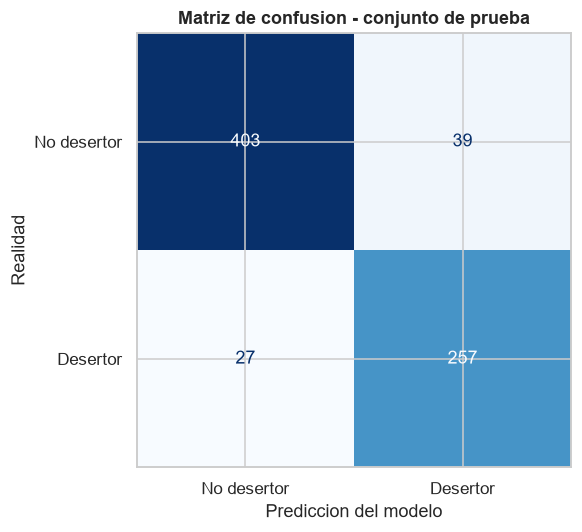

VN (correctamente no marcado) : 403
FP (falsa alarma, error barato): 39  -> 39 tutorias ofrecidas de mas
FN (NO detectado, error caro)  : 27  -> 27 estudiantes que se perdieron sin ayuda
VP (detectado a tiempo)        : 257  -> 257 oportunidades reales de intervencion


In [40]:
# ============ 5.2 Matriz de confusion ============
#
# ===== POR QUE =====
# Los 4 cuadrantes, dichos en lenguaje de la universidad y no en jerga:
#
#   VN - no iba a desertar y no se lo marco. Todo bien, no se gasto nada.
#   VP - iba a desertar y se lo detecto. El sistema hizo su trabajo: hay
#        oportunidad de intervenir (tutoria, beca, apoyo psicologico).
#   FP - se lo marco pero no iba a desertar. Cuesta una tutoria de mas.
#        Error BARATO y reversible.
#   FN - iba a desertar y el sistema NO lo marco. La intervencion que nunca
#        ocurrio. Error CARO e IRREVERSIBLE: no se puede ayudar retroactivamente
#        a alguien que ya se fue.
#
# FP y FN no cuestan lo mismo. Por eso no se optimiza el error total (accuracy)
# sino el recall: se prefiere pagar tutorias de mas antes que perder estudiantes.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No desertor', 'Desertor']).plot(
    ax=ax, cmap='Blues', values_format='d', colorbar=False
)
ax.set_title('Matriz de confusion - conjunto de prueba', weight='bold')
ax.set_xlabel('Prediccion del modelo')
ax.set_ylabel('Realidad')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '05_matriz_confusion.png', dpi=DPI_EXPORT)
plt.show()

print(f"VN (correctamente no marcado) : {vn}")
print(f"FP (falsa alarma, error barato): {fp}  -> {fp} tutorias ofrecidas de mas")
print(f"FN (NO detectado, error caro)  : {fn}  -> {fn} estudiantes que se perdieron sin ayuda")
print(f"VP (detectado a tiempo)        : {vp}  -> {vp} oportunidades reales de intervencion")

In [41]:
# ============ 5.3 Metricas de clasificacion ============
#
# ===== POR QUE (cada metrica dicha en terminos del caso) =====
#   Precision : de los que el sistema marco en riesgo, cuantos iban a desertar
#               de verdad. Baja precision = Bienestar gasta recursos de mas.
#   Recall    : de los que realmente desertaron, cuantos alcanzo a marcar.
#               ES LA METRICA CLAVE: lo que no se detecta, no se puede intervenir.
#   F1        : promedio armonico de ambas. Util para comparar modelos de un
#               solo numero cuando hay que equilibrar.
#   ROC-AUC   : capacidad de ORDENAR estudiantes por riesgo, independiente del
#               umbral. Es la metrica correcta cuando el sistema se va a usar
#               como triaje (atender de mayor a menor riesgo).
#   Accuracy  : se reporta por completitud, pero no se optimiza. El Dummy de 4.1
#               ya demostro que se puede tener accuracy alta siendo inutil.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

metricas_test = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
}

print("--- Metricas sobre el conjunto de prueba (umbral 0.5) ---")
for k, v in metricas_test.items():
    print(f"  {k:10} {v:.4f}")

print("\n--- Contra el criterio de exito declarado en la Fase 1 ---")
ok_recall = metricas_test['recall'] >= 0.80
ok_prec = metricas_test['precision'] >= 0.60
print(f"  Recall    >= 80% : {metricas_test['recall']:.2%}  "
      f"{'CUMPLE' if ok_recall else 'NO CUMPLE'}")
print(f"  Precision >= 60% : {metricas_test['precision']:.2%}  "
      f"{'CUMPLE' if ok_prec else 'NO CUMPLE'}")

print("\n--- classification_report ---")
print(classification_report(y_test, y_pred, target_names=['No desertor', 'Desertor']))

--- Metricas sobre el conjunto de prueba (umbral 0.5) ---
  accuracy   0.9091
  precision  0.8682
  recall     0.9049
  f1         0.8862
  roc_auc    0.9677

--- Contra el criterio de exito declarado en la Fase 1 ---
  Recall    >= 80% : 90.49%  CUMPLE
  Precision >= 60% : 86.82%  CUMPLE

--- classification_report ---
              precision    recall  f1-score   support

 No desertor       0.94      0.91      0.92       442
    Desertor       0.87      0.90      0.89       284

    accuracy                           0.91       726
   macro avg       0.90      0.91      0.91       726
weighted avg       0.91      0.91      0.91       726



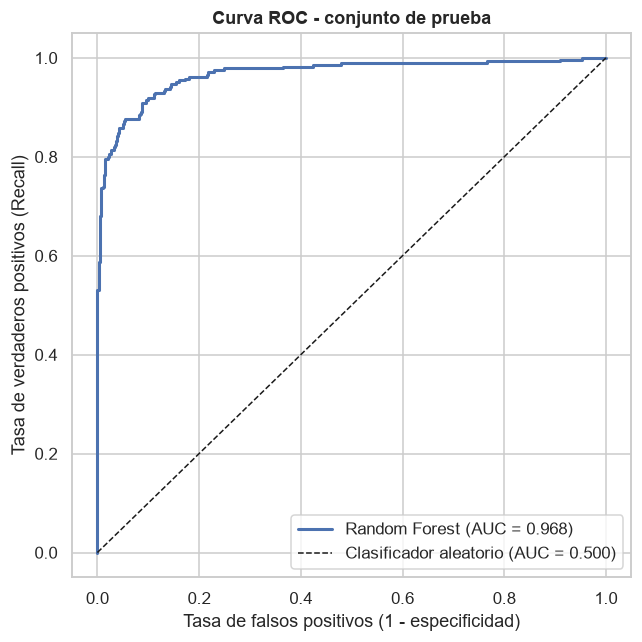

AUC = 0.9677
Interpretacion: probabilidad de que el modelo asigne mas riesgo a un
desertor tomado al azar que a un graduado tomado al azar.

        recall  precision      f1  FN (perdidos)  FP (tutorias de mas)  marcados cumple
umbral                                                                                 
0.30    0.9754     0.7309  0.8356              7                   102       379     SI
0.35    0.9542     0.7832  0.8603             13                    75       346     SI
0.40    0.9366     0.8110  0.8693             18                    62       328     SI
0.45    0.9296     0.8354  0.8800             20                    52       316     SI
0.50    0.9049     0.8682  0.8862             27                    39       296     SI
0.55    0.8732     0.9118  0.8921             36                    24       272     SI
0.60    0.8310     0.9365  0.8806             48                    16       252     SI

La columna 'cumple' marca los umbrales que satisfacen Recall>=80% 

In [42]:
# ============ 5.4 Curva ROC y analisis del umbral ============
#
# ===== POR QUE =====
# El 0.5 no es sagrado: es solo el valor por defecto de sklearn. El modelo
# devuelve una PROBABILIDAD, y donde se corta esa probabilidad es una decision
# de negocio, no tecnica.
#
# Bajar el umbral -> sube el recall (se detectan mas desertores) y baja la
# precision (mas falsas alarmas). En alerta temprana ese intercambio CONVIENE,
# porque ya establecimos que el FN es el error caro.
#
# La respuesta al "¿por que no bajar el umbral hasta detectar el 100%?": porque
# la universidad tiene capacidad finita de tutorias. El sistema es un TRIAJE:
# ordena por probabilidad y se atiende de mayor a menor riesgo hasta donde
# alcance el presupuesto. El umbral se fija donde se cruzan la capacidad real de
# intervencion y el criterio de exito.

from sklearn.metrics import roc_curve

fpr, tpr, umbrales_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, lw=2, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de falsos positivos (1 - especificidad)')
ax.set_ylabel('Tasa de verdaderos positivos (Recall)')
ax.set_title('Curva ROC - conjunto de prueba', weight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '06_curva_roc.png', dpi=DPI_EXPORT)
plt.show()

print(f"AUC = {auc:.4f}")
print("Interpretacion: probabilidad de que el modelo asigne mas riesgo a un")
print("desertor tomado al azar que a un graduado tomado al azar.\n")

# --- Barrido de umbrales contra el criterio de exito ---
filas_umbral = []
for u in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred_u = (y_proba >= u).astype(int)
    cm_u = confusion_matrix(y_test, pred_u)
    vn_u, fp_u, fn_u, vp_u = cm_u.ravel()
    filas_umbral.append({
        'umbral': u,
        'recall': recall_score(y_test, pred_u),
        'precision': precision_score(y_test, pred_u, zero_division=0),
        'f1': f1_score(y_test, pred_u),
        'FN (perdidos)': fn_u,
        'FP (tutorias de mas)': fp_u,
        'marcados': int(pred_u.sum()),
        'cumple': ('SI' if recall_score(y_test, pred_u) >= 0.80
                   and precision_score(y_test, pred_u, zero_division=0) >= 0.60 else '-'),
    })

tabla_umbrales = pd.DataFrame(filas_umbral).set_index('umbral')
print(tabla_umbrales.round(4).to_string())
print("\nLa columna 'cumple' marca los umbrales que satisfacen Recall>=80% Y Precision>=60%")
print("simultaneamente. Ese es el rango defendible; dentro de el, elegir segun la")
print("capacidad real de tutorias de la universidad.")

### 5.4.1 Curva Precision-Recall

La ROC es optimista bajo clase desbalanceada: el eje de falsos positivos se
diluye entre los muchos negativos. La curva Precision-Recall muestra
directamente el costo real de subir el recall en precision -- la misma
decision ya tomada (priorizar recall), con la visual que corresponde a un
problema desbalanceado.


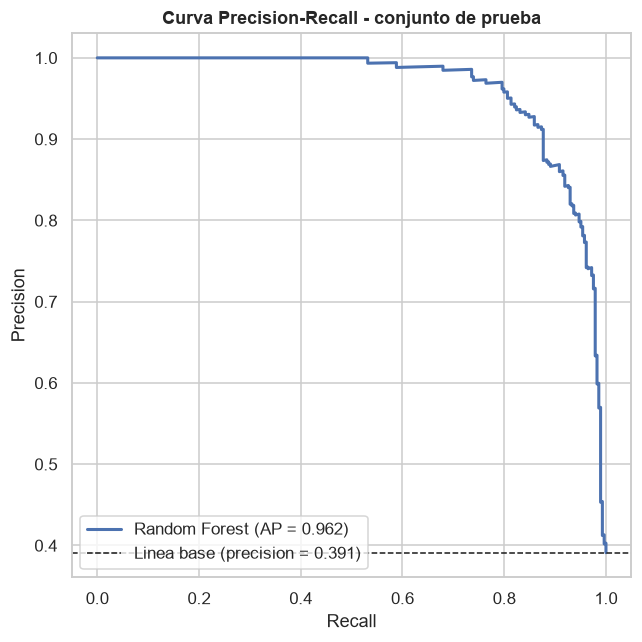

Average Precision (AP) = 0.9623
Interpretacion: resume la curva en un solo numero -- el area bajo la
curva PR. Compara contra la linea base (precision si se marcara a todos
como en riesgo), que es la referencia correcta bajo desbalance -- no 0.5
como en la ROC.


In [43]:
# ============ 5.4.1 Curva Precision-Recall ============
#
# ===== POR QUE =====
# La ROC puede ser optimista bajo desbalance de clases: el eje de falsos
# positivos se diluye entre los muchos negativos (aqui, ~60% de la muestra).
# La curva Precision-Recall muestra directamente el costo real de subir el
# recall en terminos de precision, que es exactamente el trade-off que ya
# se viene discutiendo desde 3.6 (desbalanceo) y 5.4 (analisis de umbral).
#
# Reusa y_test / y_proba, ya calculados en la celda anterior -- no se
# recalcula nada.

from sklearn.metrics import average_precision_score, precision_recall_curve

precision_c, recall_c, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
linea_base = y_test.mean()  # precision de un clasificador que marca todo como positivo

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall_c, precision_c, lw=2, label=f'Random Forest (AP = {ap:.3f})')
ax.axhline(linea_base, color='k', linestyle='--', lw=1,
           label=f'Linea base (precision = {linea_base:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall - conjunto de prueba', weight='bold')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '08_curva_precision_recall.png', dpi=DPI_EXPORT)
plt.show()

print(f"Average Precision (AP) = {ap:.4f}")
print("Interpretacion: resume la curva en un solo numero -- el area bajo la")
print("curva PR. Compara contra la linea base (precision si se marcara a todos")
print("como en riesgo), que es la referencia correcta bajo desbalance -- no 0.5")
print("como en la ROC.")


--- Top 10 por impureza (MDI) ---
remainder__Curricular units 2nd sem (approved)       0.1940
remainder__Curricular units 1st sem (approved)       0.1582
remainder__Curricular units 2nd sem (grade)          0.0900
remainder__Curricular units 1st sem (grade)          0.0889
remainder__Tuition fees up to date                   0.0517
remainder__Curricular units 2nd sem (evaluations)    0.0339
remainder__Curricular units 1st sem (evaluations)    0.0286
remainder__Age at enrollment                         0.0285
remainder__Scholarship holder                        0.0264
remainder__Admission grade                           0.0226


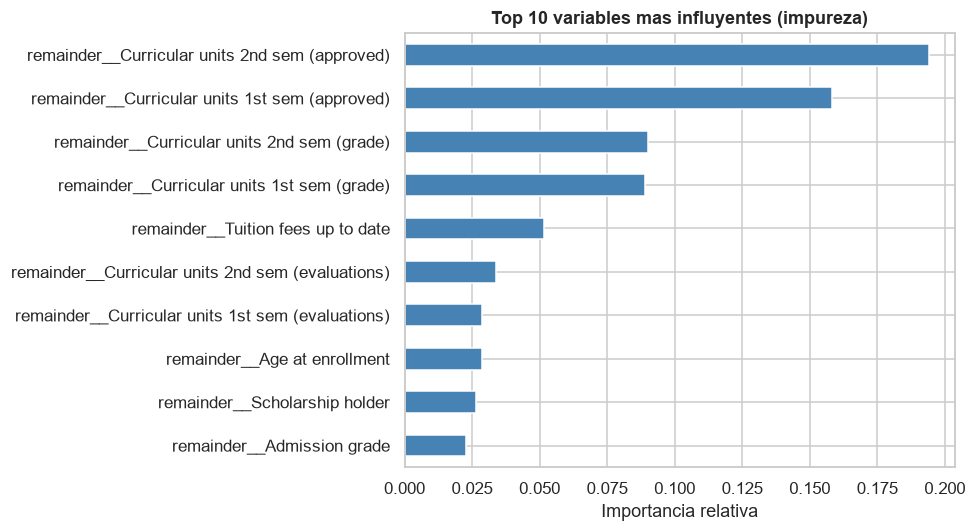

In [44]:
# ============ 5.5 Importancia de variables (top 10) ============
#
# ===== POR QUE =====
# Es probablemente la parte mas importante de la defensa: convierte el modelo en
# una POLITICA. No alcanza con predecir bien; hay que poder decirle a la
# universidad sobre que actuar.
#
# Dos mediciones, a proposito:
#   1. feature_importances_ (impureza / MDI): rapida, pero SESGADA hacia
#      variables de alta cardinalidad -- justo lo que tenemos con Father's
#      occupation (46 categorias). Confiar solo en esto seria un error.
#   2. permutation_importance sobre el conjunto de PRUEBA: mide cuanto empeora
#      el modelo al desordenar cada variable. No tiene ese sesgo. Si el ranking
#      se sostiene entre las dos, la conclusion es solida.

from sklearn.inspection import permutation_importance

nombres = modelo_final.named_steps['prep'].get_feature_names_out()
importancias = modelo_final.named_steps['clf'].feature_importances_

imp_mdi = (pd.Series(importancias, index=nombres)
           .sort_values(ascending=False)
           .head(10))

print("--- Top 10 por impureza (MDI) ---")
print(imp_mdi.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
imp_mdi.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 variables mas influyentes (impureza)', weight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '07_importancia_variables.png', dpi=DPI_EXPORT)
plt.show()

In [45]:
# --- Contraste con permutation importance (sin sesgo de cardinalidad) ---
perm = permutation_importance(
    modelo_final, X_test, y_test,
    n_repeats=10, random_state=SEMILLA, scoring='recall', n_jobs=-1,
)

imp_perm = (pd.Series(perm.importances_mean, index=X_test.columns)
            .sort_values(ascending=False)
            .head(10))

print("--- Top 10 por permutacion, sobre variables ORIGINALES (sin one-hot) ---")
print(imp_perm.round(4).to_string())

print("\n--- Comparacion de los dos rankings ---")
print("MDI se calcula sobre columnas post-one-hot; permutacion sobre las originales.")
print("Lo que hay que verificar: que las mismas FAMILIAS de variables (desempeno")
print("academico por semestre, situacion financiera) dominen en ambos.")
print("\nSi las macroeconomicas (Unemployment/Inflation/GDP) quedan abajo en las dos,")
print("eso VALIDA que el modelo aprendio del estudiante y no del ano de la cohorte.")

--- Top 10 por permutacion, sobre variables ORIGINALES (sin one-hot) ---
Tuition fees up to date                   0.0261
Curricular units 2nd sem (approved)       0.0257
Age at enrollment                         0.0151
Curricular units 2nd sem (evaluations)    0.0130
Course                                    0.0127
Scholarship holder                        0.0113
Curricular units 1st sem (evaluations)    0.0106
Curricular units 2nd sem (credited)       0.0099
Father's qualification                    0.0095
Inflation rate                            0.0092

--- Comparacion de los dos rankings ---
MDI se calcula sobre columnas post-one-hot; permutacion sobre las originales.
Lo que hay que verificar: que las mismas FAMILIAS de variables (desempeno
academico por semestre, situacion financiera) dominen en ambos.

Si las macroeconomicas (Unemployment/Inflation/GDP) quedan abajo en las dos,
eso VALIDA que el modelo aprendio del estudiante y no del ano de la cohorte.


In [46]:
# ============ 5.6 Como afecta cada variable, no solo cuanto pesa ============
#
# ===== POR QUE =====
# La importancia de variables (5.5) dice CUANTO pesa cada una, pero no en que
# DIRECCION ni a partir de que valor. Con eso solo no se puede escribir una
# politica: saber que "materias aprobadas del 2do semestre" es la variable mas
# importante no dice si hay que intervenir en 2, en 4 o en 5 materias.
#
# La DEPENDENCIA PARCIAL responde eso: recorre los valores posibles de una
# variable, y para cada valor predice sobre TODA la poblacion fijando esa
# variable en ese valor, promediando el resto. El resultado es la probabilidad
# media de desercion en funcion de esa variable.
#
# ES EL PUENTE ENTRE EL ENTREGABLE 5 Y EL 6: la importancia identifica la
# variable, la dependencia parcial da el punto de corte de la politica.
#
# ⚠️ LA LIMITACION QUE HAY QUE DECIR ANTES DE QUE LA PREGUNTEN: al promediar
# sobre el resto de las variables, este metodo ASUME QUE SON INDEPENDIENTES.
# Aca eso se viola: aprobadas de 1er y 2do semestre correlacionan a 0.916. Fijar
# "aprobadas 2do = 0" mientras el resto conserva su valor original construye
# estudiantes que en la practica casi no existen. Por eso la curva se lee como
# TENDENCIA y orden de magnitud, no como un efecto causal aislado.

from sklearn.inspection import partial_dependence

# Variables donde los DOS rankings (MDI y permutacion) coinciden, mas las dos
# binarias que disparan politicas concretas.
VARIABLES_PDP = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
]

# partial_dependence exige columnas de punto flotante: con enteros avisa que
# el recorrido de la grilla puede redondear implicitamente. Ninguna de las seis
# variables es categorica (todas pasan por `remainder='passthrough'`), asi que
# convertirlas no toca el one-hot ni cambia lo que el modelo ve.
X_pdp = X_train.copy()
X_pdp[VARIABLES_PDP] = X_pdp[VARIABLES_PDP].astype(float)

dependencia = {}
for var in VARIABLES_PDP:
    pd_res = partial_dependence(
        modelo_final, X_pdp, features=[var],
        kind='average', grid_resolution=20,
    )
    # La clave cambio de nombre entre versiones de scikit-learn.
    grilla = pd_res['grid_values'][0] if 'grid_values' in pd_res else pd_res['values'][0]
    dependencia[var] = pd.DataFrame({
        'valor': grilla,
        'prob_desercion': pd_res['average'][0],
    })

UMBRAL_PDP = 0.5
print(f"Probabilidad media de desercion segun el valor de cada variable")
print(f"(el resto de la poblacion se deja como esta y se promedia)\n")

cortes = {}
for var, tabla in dependencia.items():
    print(f"--- {var} ---")
    # Se muestran hasta 8 filas para que la tabla sea legible.
    paso = max(1, len(tabla) // 8)
    print(tabla.iloc[::paso].round(4).to_string(index=False))

    # El punto de corte: donde la probabilidad media cruza el umbral.
    encima = tabla[tabla['prob_desercion'] >= UMBRAL_PDP]
    debajo = tabla[tabla['prob_desercion'] < UMBRAL_PDP]
    if len(encima) and len(debajo):
        # La curva baja al aumentar la variable (mas materias -> menos riesgo)
        # o sube. Se detecta por el signo de la pendiente global.
        sube = tabla['prob_desercion'].iloc[-1] > tabla['prob_desercion'].iloc[0]
        corte = encima['valor'].min() if sube else encima['valor'].max()
        cortes[var] = corte
        direccion = "por encima de" if sube else "hasta"
        print(f"  -> cruza el umbral {UMBRAL_PDP}: {direccion} {corte:.2f}")
    else:
        cortes[var] = None
        estado = "siempre por encima" if len(debajo) == 0 else "nunca llega"
        print(f"  -> {estado} del umbral {UMBRAL_PDP} en todo el rango")
    print()


Probabilidad media de desercion segun el valor de cada variable
(el resto de la poblacion se deja como esta y se promedia)

--- Curricular units 2nd sem (approved) ---
 valor  prob_desercion
0.0000          0.6413
0.8421          0.6418
1.6842          0.6401
2.5263          0.6183
3.3684          0.6160
4.2105          0.4627
5.0526          0.3928
5.8947          0.3631
6.7368          0.3596
7.5789          0.3593
  -> cruza el umbral 0.5: hasta 3.37

--- Curricular units 1st sem (approved) ---
 valor  prob_desercion
0.0000          0.5616
1.0526          0.5617
2.1053          0.5609
3.1579          0.5501
4.2105          0.5209
5.2632          0.4075
6.3158          0.3805
7.3684          0.3774
8.4211          0.3773
9.4737          0.3766
  -> cruza el umbral 0.5: hasta 4.21

--- Curricular units 2nd sem (grade) ---
  valor  prob_desercion
 0.0000          0.5628
 1.5816          0.5628
 3.1633          0.5628
 4.7449          0.5628
 6.3265          0.5460
 7.9082          0.54

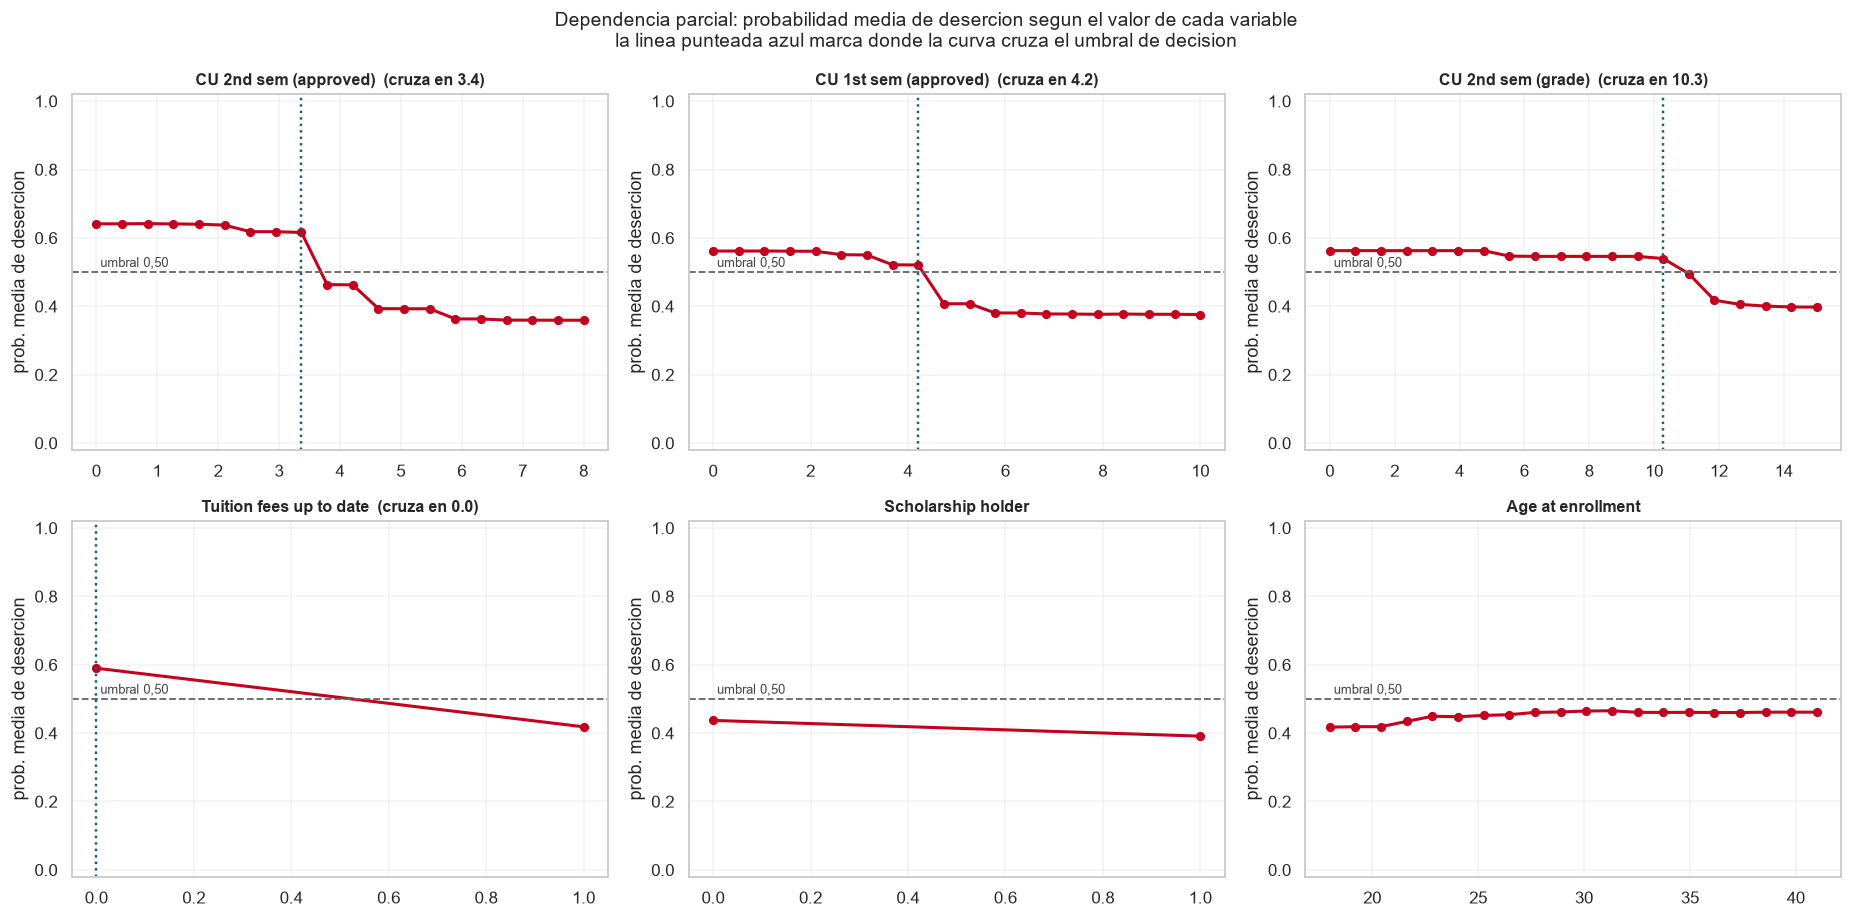

Figura guardada en D:\_Dev\Projects\DefenzaGrado\outputs\figuras\dependencia_parcial.png


In [47]:
# --- Figura: la forma de cada relacion ---
#
# La linea horizontal es el umbral de decision. Donde la curva la cruza es el
# punto en que el modelo, en promedio, pasa a marcar al estudiante.
#
# NOTA: sin numero en el nombre. Las figuras 01-08 son las del documento.

fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))

for ax, (var, tabla) in zip(axes.ravel(), dependencia.items()):
    ax.plot(tabla['valor'], tabla['prob_desercion'], 'o-',
            color='#C4001F', linewidth=2, markersize=5)
    ax.axhline(UMBRAL_PDP, color='#666', linestyle='--', linewidth=1.2)
    ax.text(tabla['valor'].iloc[0], UMBRAL_PDP + 0.015, ' umbral 0,50',
            fontsize=8.5, color='#444')

    corte = cortes.get(var)
    if corte is not None:
        ax.axvline(corte, color='#1B5E7A', linestyle=':', linewidth=1.6)

    titulo = var.replace('Curricular units', 'CU')
    if corte is not None:
        titulo += f'  (cruza en {corte:.1f})'
    ax.set_title(titulo, fontsize=10.5, fontweight='bold')
    ax.set_ylabel('prob. media de desercion')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)

fig.suptitle('Dependencia parcial: probabilidad media de desercion segun el valor de cada variable'
             + chr(10) +
             'la linea punteada azul marca donde la curva cruza el umbral de decision',
             fontsize=12.5)
fig.tight_layout()
RUTA_PDP = DIR_FIGURAS / 'dependencia_parcial.png'
fig.savefig(RUTA_PDP, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {RUTA_PDP}")


In [48]:
# --- Lectura, generada desde las curvas ---
#
# Como en 4.6 y 4.7: el veredicto se calcula, no se escribe de antemano.

print("LO QUE ESTO APORTA A LAS POLITICAS\n")

# La referencia que ya usa el reporte para explicar por que un estudiante esta
# senalado: la mediana de quienes SI se graduaron.
REFERENCIA_MEDIANA = {
    'Curricular units 2nd sem (approved)': 6,
    'Curricular units 1st sem (approved)': 6,
    'Curricular units 2nd sem (grade)': 13,
}

for var, corte in cortes.items():
    tabla = dependencia[var]
    p_min, p_max = tabla['prob_desercion'].min(), tabla['prob_desercion'].max()
    recorrido = p_max - p_min
    es_binaria = len(tabla) <= 2

    print(f"{var}:")
    print(f"   la probabilidad media va de {p_min:.4f} a {p_max:.4f} (recorrido {recorrido:.4f})")

    if recorrido < 0.05:
        print(f"   -> mover esta variable casi no cambia la probabilidad. Aparece en el")
        print(f"      ranking porque el modelo la usa para afinar, pero NO sirve como")
        print(f"      disparador de una politica por si sola")
        print()
        continue

    if es_binaria:
        fila_0 = tabla.iloc[0]
        fila_1 = tabla.iloc[-1]
        peor = fila_0 if fila_0['prob_desercion'] > fila_1['prob_desercion'] else fila_1
        mejor = fila_1 if peor is fila_0 else fila_0
        print(f"   -> con valor {int(peor['valor'])}: probabilidad {peor['prob_desercion']:.4f}"
              f"{'  (POR ENCIMA del umbral)' if peor['prob_desercion'] >= UMBRAL_PDP else ''}")
        print(f"      con valor {int(mejor['valor'])}: probabilidad {mejor['prob_desercion']:.4f}"
              f"{'  (por encima del umbral)' if mejor['prob_desercion'] >= UMBRAL_PDP else ''}")
        print(f"      la diferencia entre los dos estados es {recorrido:.4f}: es un")
        print(f"      disparador binario, o sea que la politica se activa por el estado,")
        print(f"      no por un punto de corte")
        print()
        continue

    if corte is None:
        print(f"   -> la probabilidad media nunca cruza el umbral {UMBRAL_PDP}: por si")
        print(f"      sola no alcanza para marcar, pero suma junto con las demas")
        print()
        continue

    print(f"   -> en promedio, el modelo marca en riesgo hasta un valor de {corte:.2f}")

    med = REFERENCIA_MEDIANA.get(var)
    if med is not None:
        print(f"      El reporte usa {med} como referencia (la mediana de quienes se graduaron).")
        if abs(corte - med) <= 1:
            print(f"      Coinciden: dos metodos independientes dan el mismo punto de corte.")
        elif corte < med:
            print(f"      La referencia del reporte ({med}) es MAS SENSIBLE que el punto de")
            print(f"      decision del modelo ({corte:.2f}). O sea: el reporte senala como")
            print(f"      motivo situaciones que por si solas no bastarian para marcar al")
            print(f"      estudiante. Esta bien que sea asi, y hay que saber decirlo: los")
            print(f"      motivos explican el contexto del caso, no son la decision.")
        else:
            print(f"      El modelo marca hasta {corte:.2f}, por encima de la mediana {med}:")
            print(f"      es mas sensible que la referencia del reporte.")
    print()

print("=" * 72)
print("""COMO SE USA ESTO EN LA DEFENSA

La importancia de variables (5.5) dice QUE mirar. La dependencia parcial dice
DESDE QUE VALOR actuar. Juntas convierten el entregable 5 en el 6 sin dar un
salto de fe: cada politica queda atada a un numero que salio del modelo, y no a
una intuicion razonable.

Y hay dos numeros distintos que responden dos preguntas distintas:
  - "por que ESTE estudiante": la comparacion contra la mediana de graduados,
    que es lo que aparece en la columna de motivos del reporte.
  - "por que ESTA politica" : el punto de corte de la dependencia parcial, que
    es donde el modelo mismo cambia de opinion.

No miden lo mismo y no tienen por que coincidir. Confundirlos seria el error;
tener los dos y saber cual se uso para que, es el argumento.""")


LO QUE ESTO APORTA A LAS POLITICAS

Curricular units 2nd sem (approved):
   la probabilidad media va de 0.3593 a 0.6418 (recorrido 0.2826)
   -> en promedio, el modelo marca en riesgo hasta un valor de 3.37
      El reporte usa 6 como referencia (la mediana de quienes se graduaron).
      La referencia del reporte (6) es MAS SENSIBLE que el punto de
      decision del modelo (3.37). O sea: el reporte senala como
      motivo situaciones que por si solas no bastarian para marcar al
      estudiante. Esta bien que sea asi, y hay que saber decirlo: los
      motivos explican el contexto del caso, no son la decision.

Curricular units 1st sem (approved):
   la probabilidad media va de 0.3760 a 0.5617 (recorrido 0.1858)
   -> en promedio, el modelo marca en riesgo hasta un valor de 4.21
      El reporte usa 6 como referencia (la mediana de quienes se graduaron).
      La referencia del reporte (6) es MAS SENSIBLE que el punto de
      decision del modelo (4.21). O sea: el reporte senala com

In [49]:
# ============ 5.7 ¿Esta sobreajustado el modelo? ============
#
# ===== POR QUE =====
# Es de las preguntas mas probables del tribunal, y la respuesta habitual esta
# mal: "miro el accuracy en test" dice si el modelo es bueno, no si memoriza.
#
# EL SOBREAJUSTE ES LA BRECHA entre lo que el modelo logra sobre datos que YA
# VIO y lo que logra sobre datos NUEVOS. Un modelo con 0.99 en entrenamiento y
# 0.84 en datos nuevos memoriza; uno con 0.86 y 0.84 generaliza, aunque saque
# menos en la primera columna.
#
# Se comparan las TRES mediciones que existen, que miden cosas distintas:
#   - entrenamiento: sobre las mismas 2.904 filas con las que se ajusto
#   - validacion cruzada: 5 modelos, cada uno entrenado con ~2.323 filas
#   - prueba: 726 filas que NUNCA se tocaron hasta la Fase 5

from sklearn.metrics import f1_score, recall_score, roc_auc_score

def medir(modelo, X, y):
    proba = modelo.predict_proba(X)[:, 1]
    pred = modelo.predict(X)
    return {
        'recall': recall_score(y, pred),
        'f1': f1_score(y, pred),
        'roc_auc': roc_auc_score(y, proba),
    }

fila_cv = evaluar(modelo_final, 'cv')
comparacion = pd.DataFrame([
    {'conjunto': f'Entrenamiento ({len(X_train)} filas, ya vistas)', **medir(modelo_final, X_train, y_train)},
    {'conjunto': 'Validacion cruzada (5 pliegues)', **{m: fila_cv[m] for m in ('recall', 'f1', 'roc_auc')}},
    {'conjunto': f'Prueba ({len(X_test)} filas, NUNCA vistas)', **medir(modelo_final, X_test, y_test)},
]).set_index('conjunto')

print(comparacion.round(4).to_string())

brecha = (comparacion.iloc[0]['recall'] - comparacion.iloc[2]['recall'])
print(f"\nBrecha entrenamiento - prueba en recall: {brecha:+.4f}")
print("Esa es la cifra que responde '¿esta sobreajustado?'. Cuanto mas cerca de")
print("cero, mas parecido se comporta el modelo con datos nuevos y con los que")
print("ya vio -- que es la definicion de generalizar.")


                                       recall      f1  roc_auc
conjunto                                                      
Entrenamiento (2904 filas, ya vistas)  0.9156  0.9303   0.9907
Validacion cruzada (5 pliegues)        0.8443  0.8623   0.9434
Prueba (726 filas, NUNCA vistas)       0.9049  0.8862   0.9677

Brecha entrenamiento - prueba en recall: +0.0106
Esa es la cifra que responde '¿esta sobreajustado?'. Cuanto mas cerca de
cero, mas parecido se comporta el modelo con datos nuevos y con los que
ya vio -- que es la definicion de generalizar.


Curva de aprendizaje (recall):

 filas_entrenamiento  recall_train  recall_val  val_std  brecha
                 232        0.9335      0.7995   0.0244  0.1340
                 530        0.9379      0.8241   0.0219  0.1138
                 829        0.9357      0.8382   0.0188  0.0975
                1128        0.9345      0.8435   0.0104  0.0911
                1426        0.9246      0.8355   0.0189  0.0891
                1725        0.9223      0.8320   0.0153  0.0903
                2024        0.9183      0.8347   0.0186  0.0836
                2323        0.9169      0.8443   0.0133  0.0725


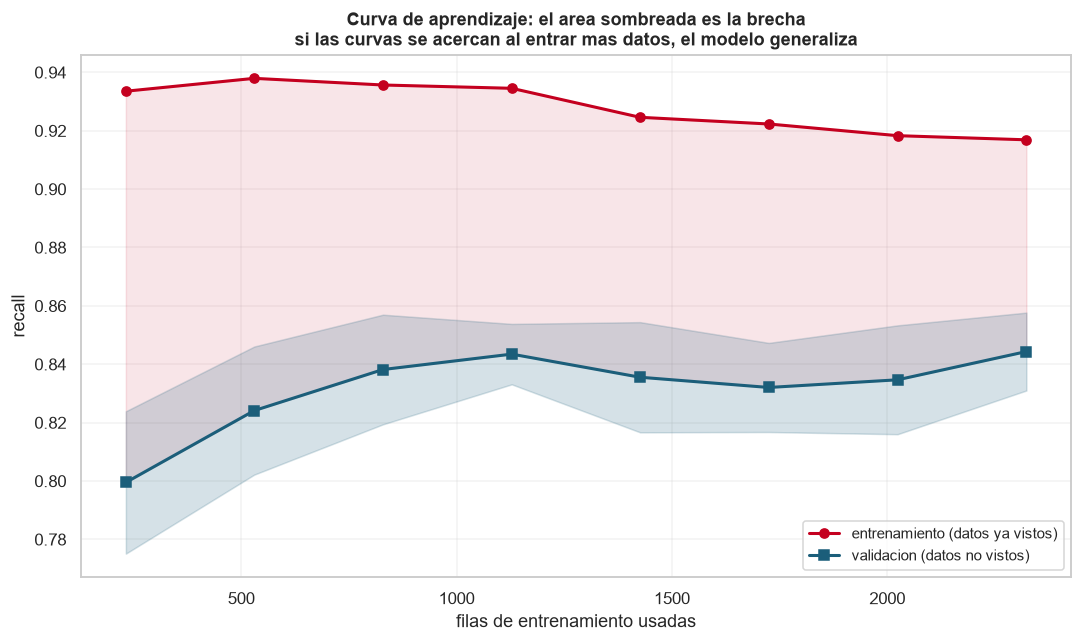


Figura guardada en D:\_Dev\Projects\DefenzaGrado\outputs\figuras\curva_aprendizaje.png


In [50]:
# --- Curva de aprendizaje: el diagnostico canonico ---
#
# ===== POR QUE =====
# Reentrena el modelo con fracciones crecientes del conjunto de entrenamiento y
# mide, en cada tamano, el desempeno sobre los datos vistos y sobre los no
# vistos. La FORMA de las dos curvas es el diagnostico:
#
#   - convergen  -> generaliza. Y ademas: mas datos no cambiarian mucho.
#   - separadas y paralelas -> sobreajusta, y mas datos SI ayudarian.
#   - las dos bajas y juntas -> subajuste: el modelo es demasiado simple.
#
# Es mas informativo que un numero suelto porque muestra la TENDENCIA: si la
# brecha se cierra a medida que entran datos, el modelo esta sano.

from sklearn.model_selection import learning_curve

tamanos, punt_train, punt_val = learning_curve(
    modelo_final, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring='recall', n_jobs=-1,
)

curva = pd.DataFrame({
    'filas_entrenamiento': tamanos,
    'recall_train': punt_train.mean(axis=1),
    'recall_val': punt_val.mean(axis=1),
    'val_std': punt_val.std(axis=1),
}).assign(brecha=lambda d: d.recall_train - d.recall_val)

print("Curva de aprendizaje (recall):\n")
print(curva.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(curva['filas_entrenamiento'], curva['recall_train'], 'o-',
        color='#C4001F', linewidth=2, label='entrenamiento (datos ya vistos)')
ax.plot(curva['filas_entrenamiento'], curva['recall_val'], 's-',
        color='#1B5E7A', linewidth=2, label='validacion (datos no vistos)')
ax.fill_between(curva['filas_entrenamiento'], curva['recall_val'], curva['recall_train'],
                color='#C4001F', alpha=0.10)
ax.fill_between(curva['filas_entrenamiento'],
                curva['recall_val'] - curva['val_std'],
                curva['recall_val'] + curva['val_std'],
                color='#1B5E7A', alpha=0.18)
ax.set_xlabel('filas de entrenamiento usadas')
ax.set_ylabel('recall')
ax.set_title('Curva de aprendizaje: el area sombreada es la brecha' + chr(10) +
             'si las curvas se acercan al entrar mas datos, el modelo generaliza',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.25)
ax.legend(fontsize=10, loc='lower right')
fig.tight_layout()
RUTA_LC = DIR_FIGURAS / 'curva_aprendizaje.png'
fig.savefig(RUTA_LC, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigura guardada en {RUTA_LC}")


In [51]:
# --- Veredicto, generado desde los numeros ---

r_train = comparacion.iloc[0]['recall']
r_cv = comparacion.iloc[1]['recall']
r_test = comparacion.iloc[2]['recall']
brecha_test = r_train - r_test
b_ini, b_fin = curva['brecha'].iloc[0], curva['brecha'].iloc[-1]

print("VEREDICTO\n")
print(f"1) Entrenamiento {r_train:.4f}  ->  prueba {r_test:.4f}   (brecha {brecha_test:+.4f})")

if brecha_test < 0.05:
    print("   La brecha es menor a 5 puntos: el modelo se comporta casi igual")
    print("   con datos nuevos que con los que ya vio. NO hay sobreajuste.")
elif brecha_test < 0.15:
    print("   Brecha moderada. Hay algo de memorizacion, pero el modelo sigue")
    print("   generalizando: la caida con datos nuevos es acotada.")
else:
    print("   Brecha grande: el modelo memoriza. Habria que regularizar mas")
    print("   (bajar max_depth, subir min_samples_leaf) -- ver 4.7.")

print(f"\n2) Prueba {r_test:.4f} vs validacion cruzada {r_cv:.4f}   ({r_test - r_cv:+.4f})")
if r_test >= r_cv:
    print("   El modelo rinde en datos que NUNCA vio igual o mejor que en")
    print("   validacion cruzada. Eso es lo contrario de sobreajustar.")
    print("   Por que pasa, y hay que saber explicarlo: en validacion cruzada")
    print(f"   cada modelo se entrena con ~{int(len(X_train) * 0.8)} filas, mientras que el modelo")
    print(f"   final se entrena con las {len(X_train)} completas. Mas datos de")
    print("   entrenamiento -> mejor modelo. Sumado a la varianza de una unica")
    print("   particion de prueba, que prueba supere a CV es esperable.")
    print("   Si estuviera sobreajustado pasaria exactamente lo contrario:")
    print("   la prueba caeria muy por debajo de la validacion cruzada.")
else:
    print("   La prueba queda por debajo de la validacion cruzada. Dentro de la")
    print("   varianza esperable de una unica particion, pero conviene mirarlo.")

print(f"\n3) Curva de aprendizaje: la brecha va de {b_ini:.4f} con "
      f"{int(curva['filas_entrenamiento'].iloc[0])} filas")
print(f"   a {b_fin:.4f} con {int(curva['filas_entrenamiento'].iloc[-1])} filas ({b_fin - b_ini:+.4f}).")
if b_fin < b_ini:
    print("   La brecha SE CIERRA al entrar mas datos: es el comportamiento de")
    print("   un modelo sano. Si memorizara, se mantendria o se abriria.")
else:
    print("   La brecha no se cierra al entrar mas datos. Conviene revisar la")
    print("   regularizacion antes de confiar en el resultado.")

ultimas = curva['recall_val'].tail(3)
mejora_final = ultimas.iloc[-1] - ultimas.iloc[0]
print(f"\n4) ¿Serviria conseguir mas datos? En el ultimo tramo la validacion")
print(f"   se movio {mejora_final:+.4f}.")
if abs(mejora_final) < 0.01:
    print("   La curva ya se aplano: mas filas del MISMO tipo aportarian poco.")
    print("   Lo que si aportaria son VARIABLES nuevas -- asistencia, uso de")
    print("   servicios de apoyo -- que hoy no se capturan. Es la recomendacion")
    print("   de instrumentacion del trabajo, y sale de este grafico.")
else:
    print("   La curva todavia sube: mas datos del mismo tipo mejorarian el modelo.")


VEREDICTO

1) Entrenamiento 0.9156  ->  prueba 0.9049   (brecha +0.0106)
   La brecha es menor a 5 puntos: el modelo se comporta casi igual
   con datos nuevos que con los que ya vio. NO hay sobreajuste.

2) Prueba 0.9049 vs validacion cruzada 0.8443   (+0.0606)
   El modelo rinde en datos que NUNCA vio igual o mejor que en
   validacion cruzada. Eso es lo contrario de sobreajustar.
   Por que pasa, y hay que saber explicarlo: en validacion cruzada
   cada modelo se entrena con ~2323 filas, mientras que el modelo
   final se entrena con las 2904 completas. Mas datos de
   entrenamiento -> mejor modelo. Sumado a la varianza de una unica
   particion de prueba, que prueba supere a CV es esperable.
   Si estuviera sobreajustado pasaria exactamente lo contrario:
   la prueba caeria muy por debajo de la validacion cruzada.

3) Curva de aprendizaje: la brecha va de 0.1340 con 232 filas
   a 0.0725 con 2323 filas (-0.0615).
   La brecha SE CIERRA al entrar mas datos: es el comportamiento de
 

In [52]:
# ============ 5.8 ¿Es realmente ALERTA TEMPRANA? Las dos ventanas ============
#
# ===== POR QUE =====
# El caso pide detectar desercion DURANTE LOS PRIMEROS 4 SEMESTRES. Y la
# variable mas importante del modelo es 'Curricular units 2nd sem (approved)'.
# De ahi sale una pregunta incomoda que hay que poder responder:
#
#   "Si tu mejor predictor es el resultado del SEGUNDO semestre, recien podes
#    avisar cuando el estudiante ya curso un ano entero. ¿Eso es temprano?"
#
# No se responde con un argumento: se mide. Se entrena el MISMO modelo, con los
# MISMOS pliegues, quitando toda la informacion del 2do semestre -- o sea, en
# el estado de conocimiento que la universidad tiene al cerrar el PRIMER
# semestre. La diferencia entre ambos recalls es, literalmente, cuanto cuesta
# avisar seis meses antes.

VARIABLES_2DO = [c for c in X.columns if '2nd sem' in c]
print(f"Variables que se quitan ({len(VARIABLES_2DO)}), todas del 2do semestre:")
for c in VARIABLES_2DO:
    print(f"   - {c}")

X_temprano = X_train.drop(columns=VARIABLES_2DO)
print(f"\nVentana completa (fin del 1er ano) : {X_train.shape[1]} variables")
print(f"Ventana temprana (fin del 1er sem) : {X_temprano.shape[1]} variables\n")

# El preprocesador se rearma porque las columnas cambiaron; el clasificador es
# el mismo, con los hiperparametros ganadores de 4.3.
cat_temprano = [c for c in COLUMNAS_CATEGORICAS if c in X_temprano.columns]
prep_temprano = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_temprano)],
    remainder='passthrough',
)
pipe_temprano = PipelineSk([
    ('prep', prep_temprano),
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_split=6, min_samples_leaf=3,
        class_weight='balanced', random_state=SEMILLA, n_jobs=-1)),
])

comparativa_ventana = pd.DataFrame([
    evaluar(modelo_final, 'Fin del 1er ano (modelo entregado)'),
    evaluar(pipe_temprano, 'Fin del 1er semestre', X_=X_temprano, y_=y_train),
]).set_index('estrategia')

print("Validacion cruzada 5-fold, mismos pliegues:\n")
print(comparativa_ventana[METRICAS].round(4).to_string())


Variables que se quitan (6), todas del 2do semestre:
   - Curricular units 2nd sem (credited)
   - Curricular units 2nd sem (enrolled)
   - Curricular units 2nd sem (evaluations)
   - Curricular units 2nd sem (approved)
   - Curricular units 2nd sem (grade)
   - Curricular units 2nd sem (without evaluations)

Ventana completa (fin del 1er ano) : 36 variables
Ventana temprana (fin del 1er sem) : 30 variables



Validacion cruzada 5-fold, mismos pliegues:

                                    accuracy  precision  recall      f1  roc_auc
estrategia                                                                      
Fin del 1er ano (modelo entregado)    0.8943     0.8811  0.8443  0.8623   0.9434
Fin del 1er semestre                  0.8740     0.8508  0.8224  0.8363   0.9233


In [53]:
# --- Lectura, generada desde los numeros ---

r_completo = comparativa_ventana.iloc[0]['recall']
r_temprano = comparativa_ventana.iloc[1]['recall']
auc_completo = comparativa_ventana.iloc[0]['roc_auc']
auc_temprano = comparativa_ventana.iloc[1]['roc_auc']
caida = r_completo - r_temprano
retiene = r_temprano / r_completo

print("¿SE PUEDE AVISAR SEIS MESES ANTES?\n")
print(f"Recall al cierre del 1er semestre : {r_temprano:.4f}")
print(f"Recall al cierre del 1er ano      : {r_completo:.4f}")
print(f"Costo de adelantar la alerta      : {caida:.4f}  "
      f"(retiene el {retiene:.1%} de la capacidad de deteccion)")
print(f"ROC-AUC: {auc_temprano:.4f} -> {auc_completo:.4f}\n")

CRITERIO_RECALL = 0.80
if r_temprano >= CRITERIO_RECALL:
    print(f"CLAVE: con solo el primer semestre el recall ({r_temprano:.4f}) YA SUPERA el")
    print(f"criterio de exito declarado en la Fase 1 ({CRITERIO_RECALL:.0%}).")
    print("O sea que el sistema SI puede operar como alerta temprana de verdad,")
    print("a mitad del primer ano, y no solo al cerrarlo. El modelo completo no")
    print("reemplaza a ese: lo refina cuando llega mas informacion.")
else:
    print(f"Con solo el primer semestre el recall ({r_temprano:.4f}) queda por debajo")
    print(f"del criterio declarado ({CRITERIO_RECALL:.0%}). La alerta preliminar sirve")
    print("para priorizar, pero la lista formal se emite al cerrar el ano.")

print(f"""
COMO SE DEFIENDE ESTO

El sistema opera en DOS MOMENTOS, no en uno:

  - Al cerrar el 1er semestre: alerta preliminar con recall {r_temprano:.4f}.
    Deja los semestres 2, 3 y 4 para intervenir.
  - Al cerrar el 1er ano: lista completa con recall {r_completo:.4f}.
    Deja los semestres 3 y 4.

Las dos ventanas caen dentro de los primeros 4 semestres, que es el periodo que
el caso define como critico. La alerta no llega tarde: llega dos veces, y cada
vez con mas informacion.

Y la diferencia de {caida:.4f} entre ambas es el argumento cuantificado para
instrumentar variables de comportamiento -- asistencia, uso de servicios de
apoyo, actividad en plataforma. Hoy no se capturan, y son las unicas que
permitirian avisar ANTES del primer cierre de notas. Esa recomendacion deja de
ser una intuicion razonable y pasa a tener un numero detras.""")


¿SE PUEDE AVISAR SEIS MESES ANTES?

Recall al cierre del 1er semestre : 0.8224
Recall al cierre del 1er ano      : 0.8443
Costo de adelantar la alerta      : 0.0220  (retiene el 97.4% de la capacidad de deteccion)
ROC-AUC: 0.9233 -> 0.9434

CLAVE: con solo el primer semestre el recall (0.8224) YA SUPERA el
criterio de exito declarado en la Fase 1 (80%).
O sea que el sistema SI puede operar como alerta temprana de verdad,
a mitad del primer ano, y no solo al cerrarlo. El modelo completo no
reemplaza a ese: lo refina cuando llega mas informacion.

COMO SE DEFIENDE ESTO

El sistema opera en DOS MOMENTOS, no en uno:

  - Al cerrar el 1er semestre: alerta preliminar con recall 0.8224.
    Deja los semestres 2, 3 y 4 para intervenir.
  - Al cerrar el 1er ano: lista completa con recall 0.8443.
    Deja los semestres 3 y 4.

Las dos ventanas caen dentro de los primeros 4 semestres, que es el periodo que
el caso define como critico. La alerta no llega tarde: llega dos veces, y cada
vez con mas 

## Fase 6 - Implementacion

Como pasa esto de un notebook a algo que la universidad realmente usa.

In [54]:
# ============ 6.1 Persistencia del modelo ============
#
# ===== POR QUE =====
# Se guarda el PIPELINE COMPLETO, no solo el clasificador. En produccion llegan
# datos crudos (las 36 columnas del CSV) y hay que aplicarles exactamente las
# mismas transformaciones del entrenamiento. Si se guardara solo el clasificador,
# habria que reproducir el one-hot a mano en el servicio y cualquier diferencia
# de orden de columnas produce predicciones silenciosamente equivocadas.
#
# El formato del dict es el que ESPERA la API ya construida en api/ (ver
# api/logica/prediccion.py: cargar_paquete valida que feature_names coincida con
# FEATURE_COLS). Guardar la version de sklearn importa porque un pickle no es
# compatible entre versiones distintas.

import joblib
import sklearn
from datetime import datetime

DIR_MODELOS = RAIZ / "models"
DIR_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_MODELO = DIR_MODELOS / "random_forest_v1.joblib"

paquete = {
    "model": modelo_final,                 # pipeline completo: preprocesador + clasificador
    "feature_names": list(X.columns),      # las 36 crudas, en el orden del CSV
    "version": "v1",
    "threshold_default": 0.5,
    "placeholder": False,                  # ya no es el sintetico de prueba
    "target_positive": "Dropout",
    "train_rows": int(len(X_train)),
    "sklearn_version": sklearn.__version__,
    "fecha_entrenamiento": datetime.now().isoformat(timespec="seconds"),
    "metricas_test": metricas_test,
}

joblib.dump(paquete, RUTA_MODELO)
print(f"Modelo guardado en: {RUTA_MODELO}")
print(f"Tamano: {RUTA_MODELO.stat().st_size / 1024:.1f} KB")
print(f"sklearn {sklearn.__version__} | entrenado con {len(X_train)} filas")
print(f"\nfeature_names ({len(paquete['feature_names'])}): coincide con lo que espera api/config.py")

Modelo guardado en: D:\_Dev\Projects\DefenzaGrado\models\random_forest_v1.joblib
Tamano: 3414.0 KB
sklearn 1.9.0 | entrenado con 2904 filas

feature_names (36): coincide con lo que espera api/config.py


In [55]:
# ============ 6.2 Funcion de prediccion para un estudiante nuevo ============
#
# ===== POR QUE =====
# Es la traduccion del modelo a algo que Bienestar Universitario pueda usar.
# Devuelve tres cosas, no una:
#   1. la probabilidad cruda (para ordenar en el triaje),
#   2. un nivel de riesgo legible (alto/medio/bajo), porque nadie en Bienestar
#      va a razonar sobre un 0.734,
#   3. los factores que mas pesaron EN ESE CASO -- sin esto el sistema es una
#      caja negra y nadie puede accionar sobre su salida.

NIVELES = [(0.70, 'ALTO'), (0.40, 'MEDIO'), (0.00, 'BAJO')]


def predecir_riesgo(datos_estudiante: dict, umbral: float = 0.5) -> dict:
    """Puntua a un estudiante a partir de sus 36 variables crudas."""
    fila = pd.DataFrame([datos_estudiante])[list(X.columns)]
    proba = float(modelo_final.predict_proba(fila)[0, 1])
    nivel = next(nombre for corte, nombre in NIVELES if proba >= corte)

    # Factores del caso: variables del top-10 global donde este estudiante
    # esta peor que la mediana de los graduados.
    factores = []
    mediana_graduados = X[y == 0].median()
    for var in ['Curricular units 2nd sem (approved)', 'Curricular units 1st sem (approved)',
                'Curricular units 2nd sem (grade)', 'Tuition fees up to date']:
        valor = datos_estudiante[var]
        if valor < mediana_graduados[var]:
            factores.append(f"{var} = {valor} (mediana de graduados: {mediana_graduados[var]:.1f})")

    return {
        'probabilidad_desercion': round(proba, 4),
        'nivel_riesgo': nivel,
        'en_riesgo': proba >= umbral,
        'factores_de_alerta': factores,
    }


# --- Prueba con dos perfiles opuestos, tomados del dataset real ---
perfil_riesgo = X[y == 1].iloc[0].to_dict()    # un desertor real
perfil_seguro = X[y == 0].iloc[0].to_dict()    # un graduado real

print("--- Perfil tomado de un DESERTOR real ---")
r = predecir_riesgo(perfil_riesgo)
print(f"  probabilidad: {r['probabilidad_desercion']}  nivel: {r['nivel_riesgo']}")
for f in r['factores_de_alerta']:
    print(f"    - {f}")

print("\n--- Perfil tomado de un GRADUADO real ---")
r = predecir_riesgo(perfil_seguro)
print(f"  probabilidad: {r['probabilidad_desercion']}  nivel: {r['nivel_riesgo']}")
for f in r['factores_de_alerta'] or ['(ningun factor de alerta)']:
    print(f"    - {f}")

--- Perfil tomado de un DESERTOR real ---
  probabilidad: 0.8451  nivel: ALTO
    - Curricular units 2nd sem (approved) = 0.0 (mediana de graduados: 6.0)
    - Curricular units 1st sem (approved) = 0.0 (mediana de graduados: 6.0)
    - Curricular units 2nd sem (grade) = 0.0 (mediana de graduados: 13.0)

--- Perfil tomado de un GRADUADO real ---
  probabilidad: 0.2833  nivel: BAJO
    - Tuition fees up to date = 0.0 (mediana de graduados: 1.0)


In [56]:
# ============ 6.3 LA DEMO: puntuar a los 794 estudiantes Enrolled ============
#
# ===== POR QUE =====
# Este es el caso de uso REAL del sistema y la demo del 13 de agosto.
# Los 'Enrolled' son estudiantes que estan cursando AHORA y cuyo desenlace nadie
# conoce todavia -- exactamente la poblacion sobre la que un sistema de alerta
# temprana tiene sentido. Por eso se los excluyo del entrenamiento en 3.1: no
# para descartarlos, sino para reservarlos para esto.
#
# El resultado NO es "estos 200 van a desertar". Es una LISTA PRIORIZADA:
# ordenada por riesgo, para atender de arriba hacia abajo hasta donde alcance la
# capacidad de tutorias. Eso es un triaje, y es lo que hay que decirle al
# tribunal cuando pregunten por los falsos positivos.

X_enrolled = df_enrolled[list(X.columns)]
proba_enrolled = modelo_final.predict_proba(X_enrolled)[:, 1]

ranking = pd.DataFrame({
    'indice_original': df_enrolled.index,
    'probabilidad_desercion': proba_enrolled,
    'Curricular units 2nd sem (approved)': df_enrolled['Curricular units 2nd sem (approved)'].values,
    'Curricular units 2nd sem (grade)': df_enrolled['Curricular units 2nd sem (grade)'].values,
    'Tuition fees up to date': df_enrolled['Tuition fees up to date'].values,
}).sort_values('probabilidad_desercion', ascending=False).reset_index(drop=True)

ranking['nivel'] = pd.cut(ranking['probabilidad_desercion'],
                          bins=[-0.01, 0.40, 0.70, 1.01],
                          labels=['BAJO', 'MEDIO', 'ALTO'])

print(f"Estudiantes actualmente matriculados puntuados: {len(ranking)}\n")
print("Distribucion por nivel de riesgo:")
print(ranking['nivel'].value_counts().reindex(['ALTO', 'MEDIO', 'BAJO']).to_string())

print("\n--- Top 15: a quienes contactar PRIMERO ---")
print(ranking.head(15).round(4).to_string(index=False))

print("\n--- Escenarios de capacidad (el argumento del triaje) ---")
for capacidad in [50, 100, 200]:
    sub = ranking.head(capacidad)
    print(f"  Con capacidad para {capacidad:3d} tutorias -> se atiende hasta "
          f"probabilidad {sub['probabilidad_desercion'].min():.3f} "
          f"(riesgo promedio del grupo: {sub['probabilidad_desercion'].mean():.3f})")

# --- Exportar la poblacion de demo para el servicio de inferencia ---
# El endpoint /reporte de la API puntua a estos mismos estudiantes. Se guarda
# con la columna Target intacta porque api/logica/reporte.py filtra por
# Target == "Enrolled" al cargarlo.
DIR_DEMO = RAIZ / "data" / "demo"
DIR_DEMO.mkdir(parents=True, exist_ok=True)
RUTA_DEMO = DIR_DEMO / "estudiantes_matriculados.csv"
df_enrolled.to_csv(RUTA_DEMO, index=False, encoding="utf-8")
print(f"\nPoblacion de demo exportada: {RUTA_DEMO}")
print(f"  {len(df_enrolled)} estudiantes, {RUTA_DEMO.stat().st_size / 1024:.1f} KB")


Estudiantes actualmente matriculados puntuados: 794

Distribucion por nivel de riesgo:
nivel
ALTO     240
MEDIO    275
BAJO     279

--- Top 15: a quienes contactar PRIMERO ---
 indice_original  probabilidad_desercion  Curricular units 2nd sem (approved)  Curricular units 2nd sem (grade)  Tuition fees up to date nivel
            3077                  0.9927                                    0                            0.0000                        0  ALTO
            2794                  0.9872                                    0                            0.0000                        1  ALTO
            2704                  0.9806                                    0                            0.0000                        1  ALTO
              64                  0.9783                                    0                            0.0000                        1  ALTO
             854                  0.9763                                    0                            0.0


Poblacion de demo exportada: D:\_Dev\Projects\DefenzaGrado\data\demo\estudiantes_matriculados.csv
  794 estudiantes, 90.4 KB


### 6.4 Plan de despliegue (redactar en el documento, no en codigo)

- **Cuando corre:** al cierre de cada semestre, sobre los estudiantes de los
  primeros 4 semestres.
- **Quien consume la salida:** Bienestar Estudiantil / Direccion de Carrera,
  como lista priorizada por probabilidad de desercion.
- **Que se hace con la alerta:** protocolo concreto de intervencion
  (tutoria academica, evaluacion socioeconomica, seguimiento).
- **Reentrenamiento:** al menos una vez al año con la nueva cohorte; el
  comportamiento estudiantil cambia y el modelo se degrada (*data drift*).
- **Monitoreo:** comparar las alertas emitidas contra la desercion real del
  periodo siguiente, y vigilar que el recall no caiga.

### 6.5 Limitaciones y consideraciones eticas

Tener esto listo: son las preguntas incomodas del tribunal.

- **Origen de los datos:** el dataset es de una institucion portuguesa. Variables
  como `Nacionality`, `Scholarship holder`, `Tuition fees up to date` o
  `Unemployment rate` no se traducen automaticamente al contexto boliviano.
  Aplicarlo en UTEPSA exigiria recalibrar con datos propios.
- **Ventana temporal:** el dataset trae rendimiento de 1er y 2do semestre. La
  prediccion sobre 4 semestres se apoya en esa ventana observable: decirlo
  explicitamente en vez de que lo descubra el tribunal.
- **Correlacion no es causalidad:** que `Tuition fees up to date` pese mucho no
  prueba que la deuda cause la desercion; puede ser sintoma de lo mismo.
- **Riesgo de estigmatizacion:** la alerta debe abrir apoyo, nunca cerrar puertas.
  Un modelo asi jamas deberia usarse para filtrar admisiones o justificar bajas.
- **Sesgo:** revisar que el modelo no penalice sistematicamente a un grupo
  (genero, nacionalidad, condicion economica). Si el recall es muy distinto entre
  subgrupos, hay un problema de equidad que hay que reportar.

---

### Checklist final antes del 13 de agosto

- [ ] Todas las celdas `# TODO` reemplazadas por codigo propio y entendido
- [ ] Notebook corre de arriba a abajo sin errores (Kernel > Restart & Run All)
- [ ] Las 8 figuras generadas en `outputs/figuras/` a 300 dpi
- [ ] Cada decision tecnica tiene su justificacion escrita
- [ ] Documento Word armado con las figuras y la tabla de metricas
- [ ] Poder explicar, sin leer, que hace Random Forest y por que este caso lo pide